# NYC Taxi Trip Duration : Regression Track

**Course:** 23CSE301 Machine Learning · Review 1

**Question:** if a yellow cab picks someone up in NYC, how many **seconds** will the trip last?

**Data file used everywhere below:** `data/nyc_taxi_trip_duration.csv`  
352,000 trips (random sample of the original 1.46M rows, seed `42`, sized to 45 MiB so GitHub will accept the push). Dates: January–June 2016. Target: **`trip_duration`**.

**Rules used in every later cluster**
- Same cleaned features for every model.
- Same test trips for every score.
- Scalers and encoders fit on **training rows only**.
- Never use `dropoff_datetime` (duration is dropoff minus pickup; that would leak the answer).
- Never use `id` (it is only a label).
- Linear / tree / boosting models train on all cleaned training rows. SVR and KNN use smaller training subsets because they are too slow otherwise.


## Notebook map

Read this once, then go cluster by cluster. Each cluster **uses the table from the cluster above**.

| Cluster | Name | What you do | What you get |
|---|---|---|---|
| **A** | Setup | Import libraries, set seed, set folders | Ready environment |
| **B** | Problem + data audit | Load the CSV and look at it | Shape, types, missing values, target stats |
| **C** | EDA | Plot the raw table | Charts + short notes on what they show |
| **D** | Data cleaning | Drop impossible trips | `df` : rows we trust |
| **E** | Feature engineering | Build distance, hour, rush-hour | `df_fe` : modelling table |
| **F** | Split, encode, scale | 80/20 split + train-only scaler | `X_train_p`, `X_test_p`, `y_train`, `y_test` |
| **G** | Ten models | Fit each algorithm on its own | Predictions and R² / RMSE / MAE |
| **H** | Compare, tune, check | Leaderboard, search, residuals, CV | Best model |
| **I** | Manual tester | Type your own trip | Predicted seconds |
| **J** | PDF report | Export plots + metrics | `results/regression_report.pdf` |


---
# Cluster A : Setup

This cluster does **not** train a model. It only loads Python libraries, sets `random_state=42`, and creates the `results/` folder so later clusters can save plots and the PDF.

**How to watch Run All (this is not a terminal)**
Jupyter writes output **into the cell that is running**, not into a console at the top. While Run All is going:

1. Look at the **left edge** of the notebook : the current cell has a spinning / filled execution icon.
2. **Scroll to that cell**. Timestamped `[HH:MM:SS]` lines appear there as soon as each step starts.
3. The status bar (bottom of Cursor) shows *Executing cell*.
4. Slow steps (Random Forest, GridSearch, SVR) also print sklearn’s own progress.

If you stay scrolled at the title, it will look like nothing is happening.


In [125]:
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    KFold,
)
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.compose import TransformedTargetRegressor
from IPython.display import display
from matplotlib.backends.backend_pdf import PdfPages

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "figure.dpi": 110,
    }
)

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("sklearn", __import__("sklearn").__version__)

# Stream logs immediately (notebooks otherwise look frozen until a cell finishes)
try:
    sys.stdout.reconfigure(line_buffering=True)
    sys.stderr.reconfigure(line_buffering=True)
except Exception:
    pass


def progress(step, detail=""):
    """Timestamped line that shows up while Run All is still going."""
    ts = time.strftime("%H:%M:%S")
    line = f"[{ts}] {step}" + (f"  |  {detail}" if detail else "")
    print(line, flush=True)
    print(line, file=sys.stderr, flush=True)

progress("Cluster A", "libraries loaded")


numpy 2.0.2
pandas 2.3.3
sklearn 1.6.1
[13:21:12] Cluster A  |  libraries loaded


[13:21:12] Cluster A  |  libraries loaded


In [126]:
# ---------------------------------------------------------------------------
# Runtime switches
# FAST_DEV=True  -> 120k-row working sample after cleaning (fast iteration)
# FAST_DEV=False -> full cleaned data for linear / tree / boosting models
# ---------------------------------------------------------------------------
FAST_DEV = False
WORKING_SAMPLE_SIZE = 120_000  # used only when FAST_DEV is True

PLOT_SAMPLE = 25_000
TEST_SIZE = 0.20
EVAL_TEST_SIZE = 50_000  # shared test sample scored by every model

# Domain cleaning bounds
NYC_LONG_MIN, NYC_LONG_MAX = -74.30, -73.70
NYC_LAT_MIN, NYC_LAT_MAX = 40.50, 40.90
MIN_DURATION_S, MAX_DURATION_S = 60, 7200  # 1 minute to 2 hours
MIN_PASSENGERS, MAX_PASSENGERS = 1, 6

# Subsets for algorithms whose training cost is super-linear in n
SVR_TRAIN_SIZE = 12_000
KNN_TRAIN_SIZE = 40_000
TUNE_SAMPLE_SIZE = 40_000  # used inside Grid/Randomized search for forest

def _first_existing(*paths):
    seen = set()
    for path in paths:
        resolved = Path(path).expanduser()
        key = str(resolved.resolve()) if resolved.exists() else str(resolved)
        if key in seen:
            continue
        seen.add(key)
        if resolved.exists():
            return resolved.resolve()
    return None


_here = Path.cwd().resolve()
_data_candidates = []
for base in [_here, *_here.parents]:
    _data_candidates.append(base / "data" / "nyc_taxi_trip_duration.csv")
_data_candidates.extend(
    [
        Path("../data/nyc_taxi_trip_duration.csv"),
        Path("data/nyc_taxi_trip_duration.csv"),
    ]
)
DATA_PATH = _first_existing(*_data_candidates)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find data/nyc_taxi_trip_duration.csv from "
        f"cwd={_here}. Open the notebook from the repo root or notebooks/ "
        "and re-run Cluster A."
    )

RESULTS_DIR = DATA_PATH.parent.parent / "results"
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
SAVED_FIGURES = []

print(f"FAST_DEV = {FAST_DEV}")
print(f"Data path: {DATA_PATH}")
print(f"Results folder: {RESULTS_DIR}")
progress("Cluster A", f"FAST_DEV={FAST_DEV}  data={DATA_PATH.name}")


FAST_DEV = False
Data path: /Users/bettim/Documents/Semester 5/Machine Learning/Capstone Evaluation/data/nyc_taxi_trip_duration.csv
Results folder: /Users/bettim/Documents/Semester 5/Machine Learning/Capstone Evaluation/results
[13:21:12] Cluster A  |  FAST_DEV=False  data=nyc_taxi_trip_duration.csv


[13:21:12] Cluster A  |  FAST_DEV=False  data=nyc_taxi_trip_duration.csv


---
# Cluster B : Problem and data audit

**What we predict:** `trip_duration` in seconds. A typical trip is about 10–15 minutes. Some rows are 1 second or almost a full day : those are errors, not real rides.

**What counts as a good model:** always guessing the training mean gives R² = 0. Every real model must beat that. We report R², RMSE, and MAE in **seconds** so the numbers stay easy to explain.

The cells below **load the same CSV** used for the rest of the notebook and print shape, column types, missing values, and the target distribution (rubric A1).


### B1. Load the CSV

This is the only place the raw file is read. Every later cluster starts from `df_raw` (or from a cleaned copy of it).


In [127]:
if "DATA_PATH" not in globals():
    raise RuntimeError("Run Cluster A first — it defines DATA_PATH.")
DATA_PATH = Path(DATA_PATH)
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"CSV not found at {DATA_PATH.resolve()}. Re-run Cluster A so the path "
        "is resolved from the kernel working directory."
    )
progress("Cluster B", f"loading {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns from {DATA_PATH.name}")
df_raw.head()


[13:21:12] Cluster B  |  loading /Users/bettim/Documents/Semester 5/Machine Learning/Capstone Evaluation/data/nyc_taxi_trip_duration.csv


[13:21:12] Cluster B  |  loading /Users/bettim/Documents/Semester 5/Machine Learning/Capstone Evaluation/data/nyc_taxi_trip_duration.csv


Loaded 352,000 rows × 11 columns from nyc_taxi_trip_duration.csv


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2979302,2,2016-04-15 07:19:25,2016-04-15 07:23:00,2,-73.9933,40.7525,-74.0008,40.7576,N,215
1,id1901673,1,2016-05-28 23:25:47,2016-05-28 23:57:57,4,-73.7836,40.6487,-73.9728,40.7556,N,1930
2,id2241407,2,2016-02-22 09:43:15,2016-02-22 10:02:32,2,-73.9491,40.7733,-73.9684,40.7623,N,1157
3,id1614454,2,2016-05-18 10:45:48,2016-05-18 10:50:04,5,-73.9894,40.7402,-73.9848,40.7422,N,256
4,id0439485,2,2016-05-05 21:27:15,2016-05-05 21:32:05,1,-73.9907,40.7509,-73.9895,40.7567,N,290


### B2. Column types and missing values

If a column has missing values we would need an imputation plan. This file should show **zero missing cells**.


In [128]:
audit = pd.DataFrame(
    {
        "dtype": df_raw.dtypes.astype(str),
        "non_null": df_raw.notna().sum(),
        "missing": df_raw.isna().sum(),
        "missing_pct": 100 * df_raw.isna().mean(),
        "n_unique": df_raw.nunique(),
    }
)
audit


,dtype,non_null,missing,missing_pct,n_unique
id,object,352000,0,0.0000,352000
vendor_id,int64,352000,0,0.0000,2
pickup_datetime,object,352000,0,0.0000,347174
dropoff_datetime,object,352000,0,0.0000,347284
passenger_count,int64,352000,0,0.0000,7
pickup_longitude,float64,352000,0,0.0000,16616
pickup_latitude,float64,352000,0,0.0000,34555
dropoff_longitude,float64,352000,0,0.0000,22427
dropoff_latitude,float64,352000,0,0.0000,44349
store_and_fwd_flag,object,352000,0,0.0000,2


In [129]:
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("Duplicate ids:", int(df_raw["id"].duplicated().sum()))
print()
print("vendor_id")
print(df_raw["vendor_id"].value_counts().sort_index().to_string())
print()
print("store_and_fwd_flag")
print(df_raw["store_and_fwd_flag"].value_counts().to_string())
print()
print("passenger_count")
print(df_raw["passenger_count"].value_counts().sort_index().to_string())
print()
print("trip_duration (seconds)")
display(df_raw["trip_duration"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame())
print(
    f"pickup_datetime range: {df_raw['pickup_datetime'].min()}  →  {df_raw['pickup_datetime'].max()}"
)


Duplicate rows: 0
Duplicate ids: 0

vendor_id
vendor_id
1    164074
2    187926

store_and_fwd_flag
store_and_fwd_flag
N    350085
Y      1915

passenger_count
passenger_count
0        12
1    249398
2     50572
3     14424
4      6956
5     19008
6     11630

trip_duration (seconds)


,trip_duration
count,"352,000.0000"
mean,947.9198
std,"3,117.5860"
min,1.0000
1%,89.0000
5%,181.0000
25%,397.0000
50%,661.0000
75%,"1,074.0000"
95%,"2,104.0000"


pickup_datetime range: 2016-01-01 00:01:20  →  2016-06-30 23:57:49


---
# Cluster C : Exploratory data analysis (EDA)

**Goal:** see the data *before* cleaning so we know what to fix and which features might predict duration.

Plots use a random **25,000-row sample** of `df_raw` (seed 42) so drawing stays fast. Numbers printed under a plot still use the **full 352,000-row table**.

Required charts: feature distributions, target distribution, correlation heatmap, at least two feature–target scatters (rubric A2). Each chart has a short note under it (rubric A3).


### C1. Plot helpers

`take_plot_sample` draws the 25k points. `finalise` titles the axes, **saves a PNG into `results/figures/`**, and shows the figure. Cluster J will pack those PNGs into the PDF.


In [130]:
progress("Cluster C", "EDA helpers + plot sample")
def take_plot_sample(frame: pd.DataFrame, n: int = PLOT_SAMPLE) -> pd.DataFrame:
    if len(frame) <= n:
        return frame.copy()
    return frame.sample(n, random_state=RANDOM_STATE)


def finalise(fig=None, name=None):
    plt.tight_layout()
    fig = fig or plt.gcf()
    if name is None:
        titles = [ax.get_title() for ax in fig.axes if ax.get_title()]
        name = titles[0] if titles else "figure"
    slug = "".join(ch if ch.isalnum() else "_" for ch in name.lower())
    slug = "_".join(part for part in slug.split("_") if part)[:70]
    path = FIG_DIR / f"{len(SAVED_FIGURES) + 1:02d}_{slug}.png"
    fig.savefig(path, bbox_inches="tight", dpi=140)
    SAVED_FIGURES.append(path)
    plt.show()


eda = df_raw.copy()
eda["pickup_datetime"] = pd.to_datetime(eda["pickup_datetime"])
eda["pickup_hour"] = eda["pickup_datetime"].dt.hour
eda["pickup_dayofweek"] = eda["pickup_datetime"].dt.dayofweek
eda["log1p_duration"] = np.log1p(eda["trip_duration"])
plot_df = take_plot_sample(eda)
print(f"EDA plot sample: {len(plot_df):,} rows")


[13:21:13] Cluster C  |  EDA helpers + plot sample


[13:21:13] Cluster C  |  EDA helpers + plot sample


EDA plot sample: 25,000 rows


[13:21:13] Cluster C  |  plot: target distribution


[13:21:13] Cluster C  |  plot: target distribution


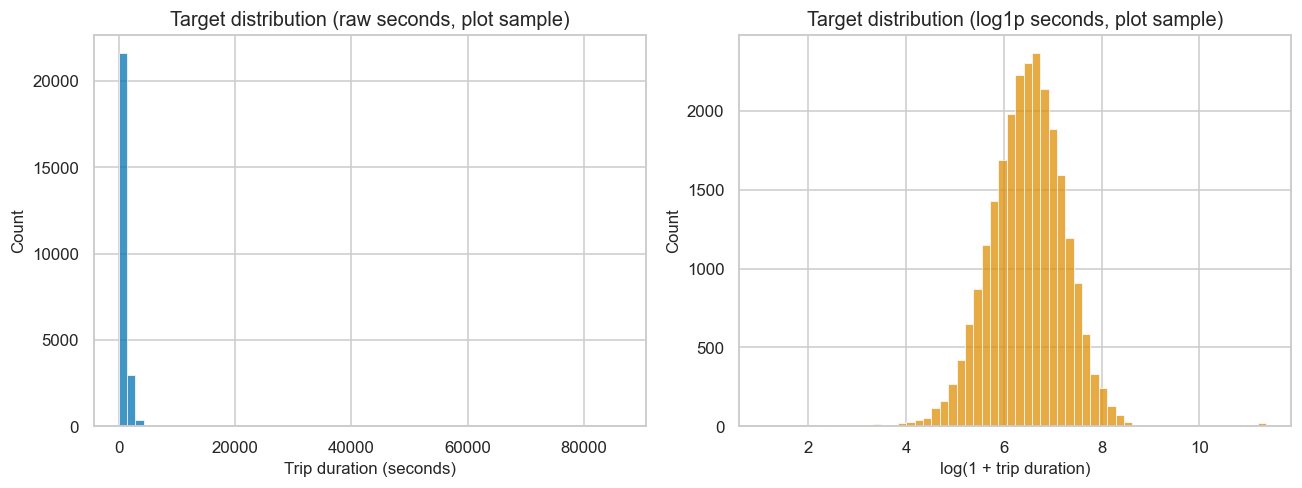

Skewness of trip_duration (full data): 25.64  |  skewness of log1p: -0.28
Median = 661s  |  mean = 948s  |  99th percentile = 3420s


In [131]:
progress("Cluster C", "plot: target distribution")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.histplot(plot_df["trip_duration"], bins=60, ax=axes[0], color=sns.color_palette("colorblind")[0])
axes[0].set_title("Target distribution (raw seconds, plot sample)")
axes[0].set_xlabel("Trip duration (seconds)")
axes[0].set_ylabel("Count")

sns.histplot(plot_df["log1p_duration"], bins=60, ax=axes[1], color=sns.color_palette("colorblind")[1])
axes[1].set_title("Target distribution (log1p seconds, plot sample)")
axes[1].set_xlabel("log(1 + trip duration)")
axes[1].set_ylabel("Count")

finalise(fig)
print(
    f"Skewness of trip_duration (full data): {eda['trip_duration'].skew():.2f}  |  "
    f"skewness of log1p: {eda['log1p_duration'].skew():.2f}"
)
print(
    f"Median = {eda['trip_duration'].median():.0f}s  |  "
    f"mean = {eda['trip_duration'].mean():.0f}s  |  "
    f"99th percentile = {eda['trip_duration'].quantile(0.99):.0f}s"
)


**Reading this plot.** Most trips are 5–15 minutes. A long tail of very large values stretches the x-axis. After `log1p` the shape is much more even but we still **predict raw seconds**, so RMSE of 400 means “off by about 6–7 minutes.” Cluster D will drop the crazy tail (under 1 minute or over 2 hours).


[13:21:14] Cluster C  |  plot: passenger / vendor / hour


[13:21:14] Cluster C  |  plot: passenger / vendor / hour


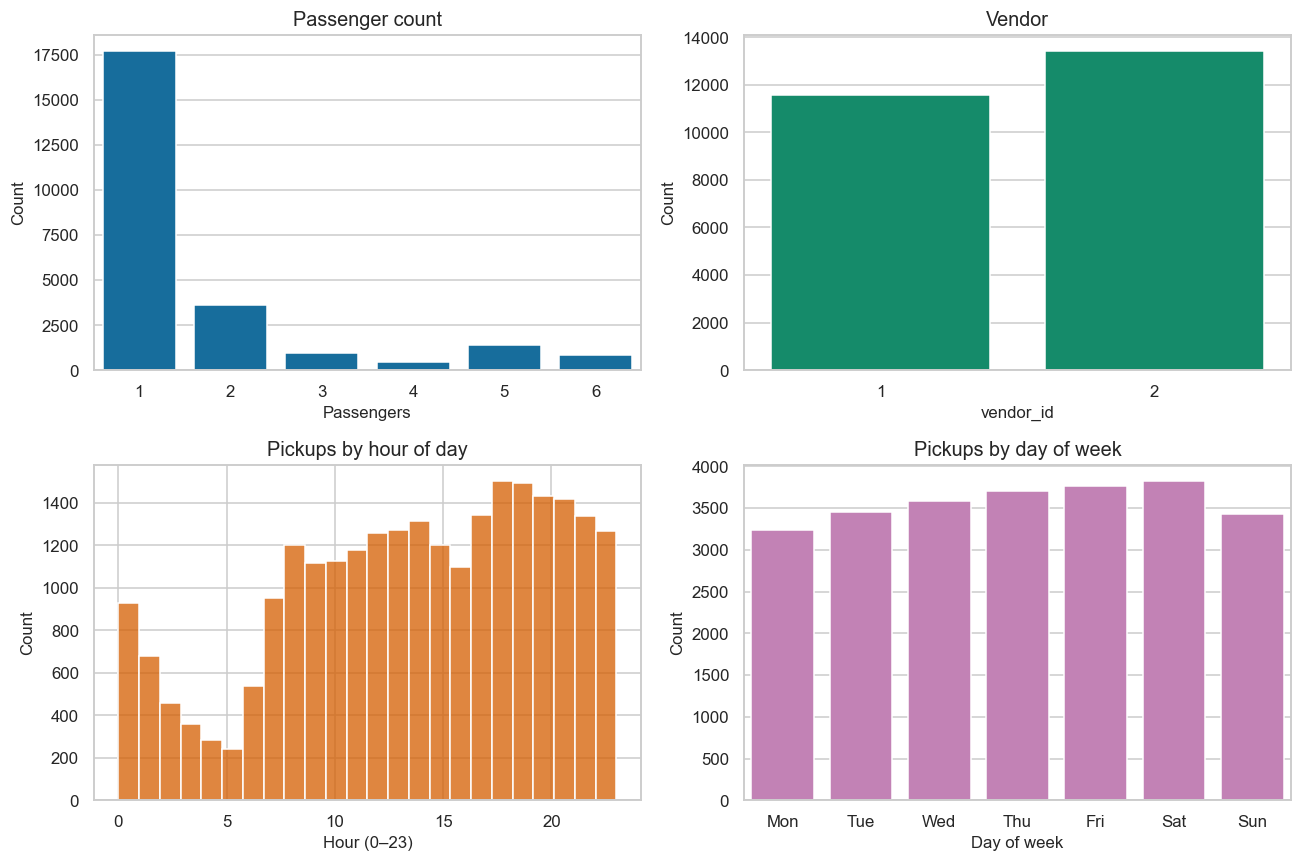

In [132]:
progress("Cluster C", "plot: passenger / vendor / hour")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(data=plot_df, x="passenger_count", ax=axes[0, 0], color=sns.color_palette("colorblind")[0])
axes[0, 0].set_title("Passenger count")
axes[0, 0].set_xlabel("Passengers")
axes[0, 0].set_ylabel("Count")

sns.countplot(data=plot_df, x="vendor_id", ax=axes[0, 1], color=sns.color_palette("colorblind")[2])
axes[0, 1].set_title("Vendor")
axes[0, 1].set_xlabel("vendor_id")
axes[0, 1].set_ylabel("Count")

sns.histplot(plot_df["pickup_hour"], bins=24, ax=axes[1, 0], color=sns.color_palette("colorblind")[3])
axes[1, 0].set_title("Pickups by hour of day")
axes[1, 0].set_xlabel("Hour (0–23)")
axes[1, 0].set_ylabel("Count")

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.countplot(data=plot_df, x="pickup_dayofweek", ax=axes[1, 1], color=sns.color_palette("colorblind")[4])
axes[1, 1].set_title("Pickups by day of week")
axes[1, 1].set_xlabel("Day of week")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_xticks(range(7), dow_labels)

finalise(fig)


**Reading this plot.** Most riders travel **alone**. Pickups are quiet at night, busy from late morning through evening. Saturday is busy; Monday is quieter. Vendor 2 appears a bit more than vendor 1. These charts do not predict duration by themselves, but they tell us hour-of-day and weekend flags are worth adding in Cluster E.


[13:21:14] Cluster C  |  plot: pickup / dropoff map


[13:21:14] Cluster C  |  plot: pickup / dropoff map


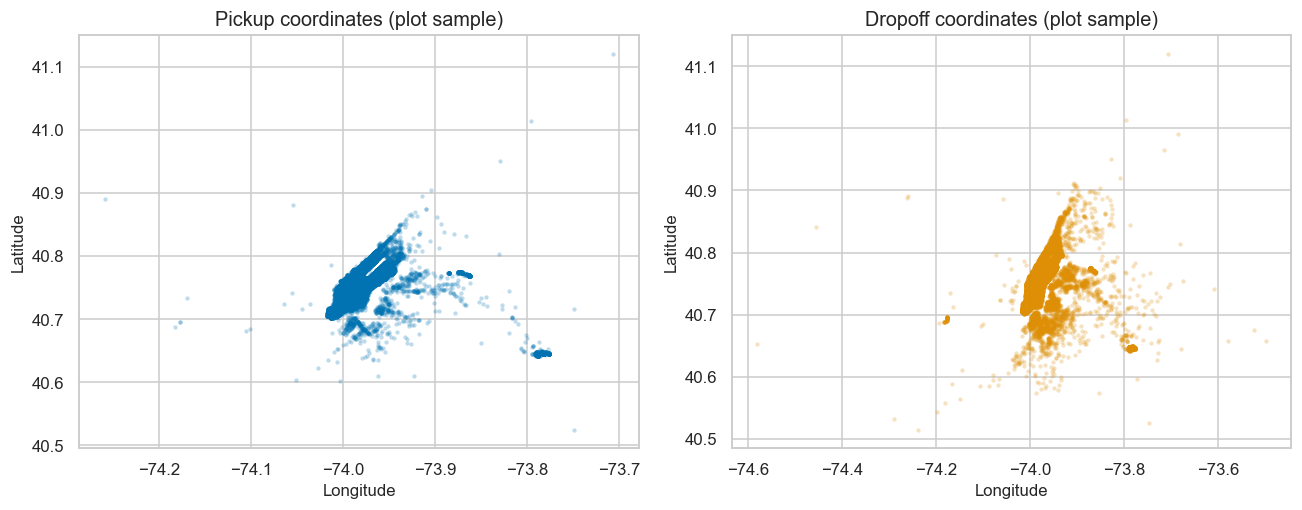

Pickup longitude range: -121.93334197998048 → -72.07433319091797
Pickup latitude range: 35.310306549072266 → 41.69679641723633


In [133]:
progress("Cluster C", "plot: pickup / dropoff map")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.scatterplot(
    data=plot_df,
    x="pickup_longitude",
    y="pickup_latitude",
    s=8,
    alpha=0.25,
    ax=axes[0],
    linewidth=0,
)
axes[0].set_title("Pickup coordinates (plot sample)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

sns.scatterplot(
    data=plot_df,
    x="dropoff_longitude",
    y="dropoff_latitude",
    s=8,
    alpha=0.25,
    ax=axes[1],
    linewidth=0,
    color=sns.color_palette("colorblind")[1],
)
axes[1].set_title("Dropoff coordinates (plot sample)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

finalise(fig)
print("Pickup longitude range:", eda["pickup_longitude"].min(), "→", eda["pickup_longitude"].max())
print("Pickup latitude range:", eda["pickup_latitude"].min(), "→", eda["pickup_latitude"].max())


**Reading this plot.** Real trips sit in Manhattan / Brooklyn / Queens, plus JFK and LaGuardia. A few points are thousands of kilometres away those would create fake “long distance” features. Cluster D keeps only longitude [−74.30, −73.70] and latitude [40.50, 40.90].


[13:21:14] Cluster C  |  plot: distance vs duration


[13:21:14] Cluster C  |  plot: distance vs duration


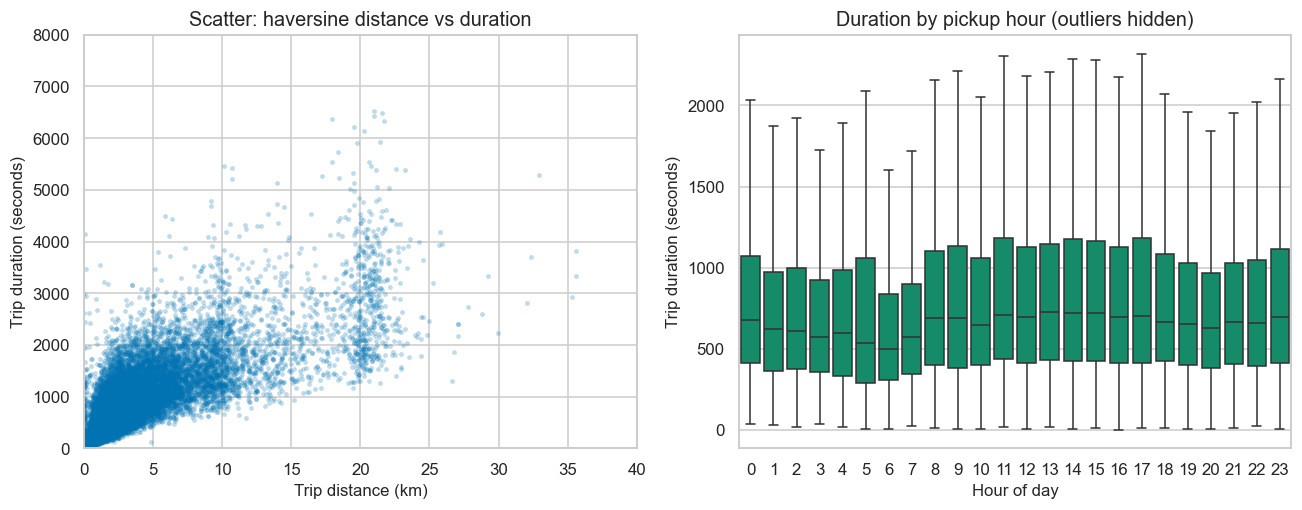

Pearson correlation (distance, duration) on full data: 0.160


In [134]:
progress("Cluster C", "plot: distance vs duration")
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = (np.radians(lat1), np.radians(lon1), np.radians(lat2), np.radians(lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2.0 * r * np.arcsin(np.sqrt(a))


eda["trip_distance_km"] = haversine_km(
    eda["pickup_latitude"].to_numpy(),
    eda["pickup_longitude"].to_numpy(),
    eda["dropoff_latitude"].to_numpy(),
    eda["dropoff_longitude"].to_numpy(),
)
plot_df = take_plot_sample(eda)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.scatterplot(
    data=plot_df,
    x="trip_distance_km",
    y="trip_duration",
    s=10,
    alpha=0.25,
    ax=axes[0],
    linewidth=0,
)
axes[0].set_title("Scatter: haversine distance vs duration")
axes[0].set_xlabel("Trip distance (km)")
axes[0].set_ylabel("Trip duration (seconds)")
axes[0].set_xlim(0, 40)
axes[0].set_ylim(0, 8000)

sns.boxplot(
    data=plot_df,
    x="pickup_hour",
    y="trip_duration",
    showfliers=False,
    ax=axes[1],
    color=sns.color_palette("colorblind")[2],
)
axes[1].set_title("Duration by pickup hour (outliers hidden)")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Trip duration (seconds)")

finalise(fig)

corr_distance = eda[["trip_distance_km", "trip_duration"]].corr().iloc[0, 1]
print(f"Pearson correlation (distance, duration) on full data: {corr_distance:.3f}")


**Reading this plot.** Longer trips *should* take longer, but on the **raw** table the correlation is weak because 24-hour outliers wreck it. After cleaning (Cluster D) this same scatter becomes a clear upward band. The hour boxplot already shows congestion: afternoon trips last longer even when we hide outliers. That is why we will add `pickup_hour` and `is_rush_hour`.


[13:21:15] Cluster C  |  plot: raw correlation heatmap


[13:21:15] Cluster C  |  plot: raw correlation heatmap


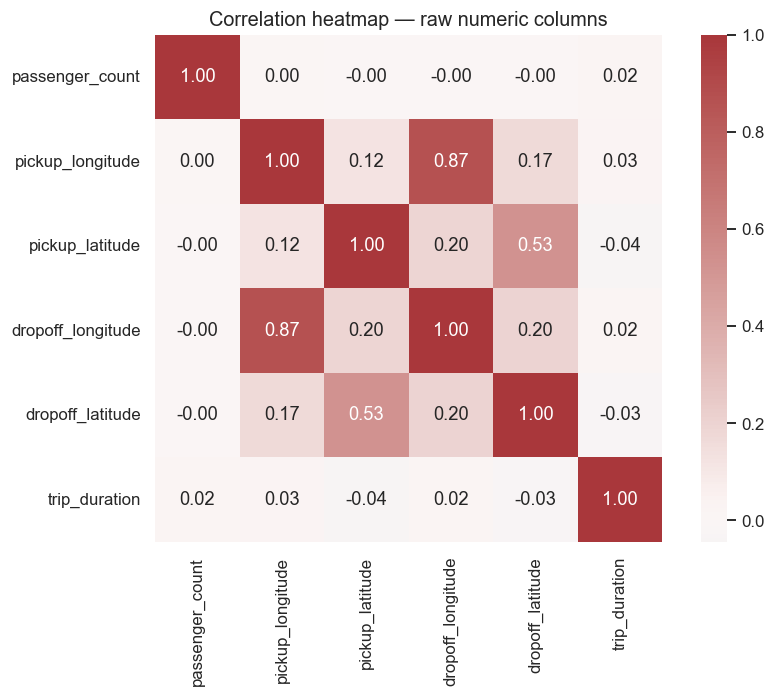

In [135]:
progress("Cluster C", "plot: raw correlation heatmap")
raw_numeric = [
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration",
]
corr_raw = eda[raw_numeric].corr()

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(
    corr_raw,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    ax=ax,
    square=True,
)
ax.set_title("Correlation heatmap — raw numeric columns")
finalise(fig)


**Reading this plot.** Raw lat/long barely correlate with duration — a point on a map is not a trip length. Passenger count also does almost nothing. What we need is **how far the cab moved**, which Cluster E builds (haversine + Manhattan distance). A second heatmap after engineering uses the columns we actually model with.


---
# Cluster D : Data cleaning

**Input:** `df_raw` (352,000 rows).  
**Output:** `df` : the same columns, minus `id` and `dropoff_datetime`, with impossible rows removed.

We do **not** silently call `dropna()`. Each rule is written down. We also do **not** IQR-trim duration after the 60 s–2 h cap: airport runs are long but real, and IQR would delete them.


### D1. Cleaning rules

| Rule | Why |
|---|---|
| Drop duplicate rows | Safety check (this file has none) |
| Drop `id` | Not a predictor |
| Drop `dropoff_datetime` | **Leakage** — it already contains the answer |
| Keep NYC bounding box | Drop GPS junk outside the city |
| `passenger_count` 1–6 | 0 is invalid; 7+ is not a yellow cab |
| `trip_duration` 60–7200 s | Drop cancelled trips and multi-hour logging errors |


In [136]:
progress("Cluster D", "cleaning impossible trips")
def apply_cleaning(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    tracker = []

    def log(step, before, after, note):
        tracker.append(
            {
                "step": step,
                "rows_before": before,
                "rows_after": after,
                "rows_removed": before - after,
                "pct_removed": 100 * (before - after) / before if before else 0.0,
                "note": note,
            }
        )

    out = frame.copy()
    n0 = len(out)
    log("loaded", n0, n0, "raw file")

    before = len(out)
    out = out.drop_duplicates()
    log("drop duplicate rows", before, len(out), "exact row duplicates")

    before = len(out)
    out = out.drop(columns=["id", "dropoff_datetime"])
    log("drop leakage / id columns", before, len(out), "id + dropoff_datetime removed (column drop only)")

    before = len(out)
    in_box = (
        out["pickup_longitude"].between(NYC_LONG_MIN, NYC_LONG_MAX)
        & out["pickup_latitude"].between(NYC_LAT_MIN, NYC_LAT_MAX)
        & out["dropoff_longitude"].between(NYC_LONG_MIN, NYC_LONG_MAX)
        & out["dropoff_latitude"].between(NYC_LAT_MIN, NYC_LAT_MAX)
    )
    out = out.loc[in_box]
    log("NYC bounding box", before, len(out), "[-74.30,-73.70] × [40.50,40.90]")

    before = len(out)
    out = out.loc[out["passenger_count"].between(MIN_PASSENGERS, MAX_PASSENGERS)]
    log("passenger_count 1–6", before, len(out), "drop 0 and 7+")

    before = len(out)
    out = out.loc[out["trip_duration"].between(MIN_DURATION_S, MAX_DURATION_S)]
    log("duration 60–7200 s", before, len(out), "drop cancelled / multi-day trips")

    out = out.reset_index(drop=True)
    report = pd.DataFrame(tracker)
    return out, report


df, cleaning_report = apply_cleaning(df_raw)
display(cleaning_report)
print(f"Cleaned table: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Retained {100 * len(df) / len(df_raw):.2f}% of the original file")


[13:21:15] Cluster D  |  cleaning impossible trips


[13:21:15] Cluster D  |  cleaning impossible trips


,step,rows_before,rows_after,rows_removed,pct_removed,note
0,loaded,352000,352000,0,0.0000,raw file
1,drop duplicate rows,352000,352000,0,0.0000,exact row duplicates
2,drop leakage / id columns,352000,352000,0,0.0000,id + dropoff_datetime removed (column drop only)
3,NYC bounding box,352000,351601,399,0.1134,"[-74.30,-73.70] × [40.50,40.90]"
4,passenger_count 1–6,351601,351589,12,0.0034,drop 0 and 7+
5,duration 60–7200 s,351589,349080,2509,0.7136,drop cancelled / multi-day trips


Cleaned table: 349,080 rows × 9 columns
Retained 99.17% of the original file


**After cleaning.** Almost all rows are kept. The duration cap removes the values that would have dominated RMSE. The bounding box removes fake thousand-kilometre trips. Missingness is still zero, so we do not impute anything.


---
# Cluster E : Feature engineering

**Input:** cleaned `df`.  
**Output:** `df_fe` : `df` plus new columns, with `pickup_datetime` replaced by hour / day / month flags.

We only create features you could know when the passenger is picked up (dropoff *location* is the destination; dropoff *time* is not).  
**We never create `speed = distance / duration`.** That uses the target.


### E1. New columns and why they exist

| New column | How | Why it should help |
|---|---|---|
| `trip_distance_km` | Haversine (straight-line km) | Main physical driver of duration |
| `manhattan_distance_km` | Grid-style \|Δlat\| + \|Δlon\| | NYC streets are a grid |
| `bearing_deg` | Compass direction of the trip | Airports vs downtown corridors |
| `pickup_hour`, `pickup_dayofweek`, `pickup_month` | From pickup timestamp | Traffic changes through the day / week |
| `is_weekend` | Sat/Sun flag | Leisure vs commute |
| `is_rush_hour` | Weekday 07–09 or 16–19 | Same distance, worse duration in peak traffic |


In [137]:
progress("Cluster E", "engineering distance / time features")
def manhattan_km(lat1, lon1, lat2, lon2):
    lat_km = 111.32
    lon_km = 111.32 * np.cos(np.radians((lat1 + lat2) / 2.0))
    return lat_km * np.abs(lat2 - lat1) + lon_km * np.abs(lon2 - lon1)


def bearing_deg(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = (np.radians(lat1), np.radians(lon1), np.radians(lat2), np.radians(lon2))
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return (np.degrees(np.arctan2(x, y)) + 360.0) % 360.0


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["pickup_datetime"] = pd.to_datetime(out["pickup_datetime"])
    lat1 = out["pickup_latitude"].to_numpy()
    lon1 = out["pickup_longitude"].to_numpy()
    lat2 = out["dropoff_latitude"].to_numpy()
    lon2 = out["dropoff_longitude"].to_numpy()

    out["trip_distance_km"] = haversine_km(lat1, lon1, lat2, lon2)
    out["manhattan_distance_km"] = manhattan_km(lat1, lon1, lat2, lon2)
    out["bearing_deg"] = bearing_deg(lat1, lon1, lat2, lon2)
    out["pickup_hour"] = out["pickup_datetime"].dt.hour.astype(int)
    out["pickup_dayofweek"] = out["pickup_datetime"].dt.dayofweek.astype(int)
    out["pickup_month"] = out["pickup_datetime"].dt.month.astype(int)
    out["is_weekend"] = (out["pickup_dayofweek"] >= 5).astype(int)
    rush = out["pickup_hour"].isin([7, 8, 9, 16, 17, 18, 19]) & (out["is_weekend"] == 0)
    out["is_rush_hour"] = rush.astype(int)
    out = out.drop(columns=["pickup_datetime"])
    return out


df_fe = engineer_features(df)

if FAST_DEV and len(df_fe) > WORKING_SAMPLE_SIZE:
    df_fe = df_fe.sample(WORKING_SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"FAST_DEV on: working sample is {len(df_fe):,} rows")
else:
    print(f"Modelling table: {len(df_fe):,} rows (full cleaned data)")

print("Engineered columns added: trip_distance_km, manhattan_distance_km, bearing_deg,")
print("pickup_hour, pickup_dayofweek, pickup_month, is_weekend, is_rush_hour")
df_fe.head()


[13:21:15] Cluster E  |  engineering distance / time features


[13:21:15] Cluster E  |  engineering distance / time features


Modelling table: 349,080 rows (full cleaned data)
Engineered columns added: trip_distance_km, manhattan_distance_km, bearing_deg,
pickup_hour, pickup_dayofweek, pickup_month, is_weekend, is_rush_hour


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_distance_km,manhattan_distance_km,bearing_deg,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour
0,2,2,-73.9933,40.7525,-74.0008,40.7576,N,215,0.8538,1.2068,311.7018,7,4,4,0,1
1,1,4,-73.7836,40.6487,-73.9728,40.7556,N,1930,19.8926,27.8675,306.7405,23,5,5,1,0
2,2,2,-73.9491,40.7733,-73.9684,40.7623,N,1157,2.0265,2.8401,233.1592,9,0,2,0,1
3,2,5,-73.9894,40.7402,-73.9848,40.7422,N,256,0.4440,0.6044,60.9667,10,2,5,0,0
4,2,1,-73.9907,40.7509,-73.9895,40.7567,N,290,0.6572,0.7462,8.3211,21,3,5,0,0


[13:21:15] Cluster E  |  plot: engineered heatmap


[13:21:15] Cluster E  |  plot: engineered heatmap


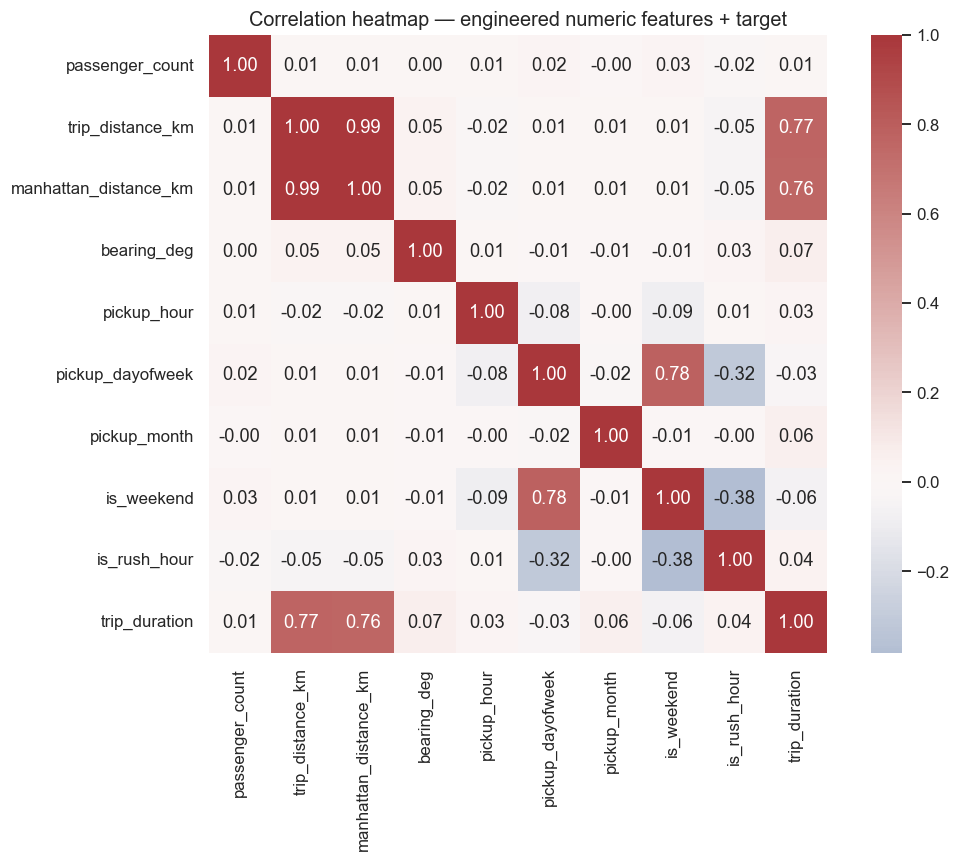

Correlation with trip_duration:
trip_distance_km         0.7714
manhattan_distance_km    0.7579
bearing_deg              0.0666
is_weekend              -0.0650
pickup_month             0.0569
is_rush_hour             0.0395
pickup_dayofweek        -0.0347
pickup_hour              0.0284
passenger_count          0.0146


In [138]:
progress("Cluster E", "plot: engineered heatmap")
engineered_cols = [
    "passenger_count",
    "trip_distance_km",
    "manhattan_distance_km",
    "bearing_deg",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend",
    "is_rush_hour",
    "trip_duration",
]
corr_fe = df_fe[engineered_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_fe,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    ax=ax,
    square=True,
)
ax.set_title("Correlation heatmap — engineered numeric features + target")
finalise(fig)

print("Correlation with trip_duration:")
print(corr_fe["trip_duration"].drop("trip_duration").sort_values(key=np.abs, ascending=False).to_string())


**Reading this heatmap.** After cleaning, **distance columns correlate ~0.7+ with duration**. They also correlate with each other — that is why Ridge / Lasso / ElasticNet exist. `is_rush_hour` is a weaker *linear* correlation but still useful: same kilometres, worse time. This is the heatmap for the features we actually train on.


[13:21:16] Cluster E  |  plot: cleaned distance vs duration


[13:21:16] Cluster E  |  plot: cleaned distance vs duration


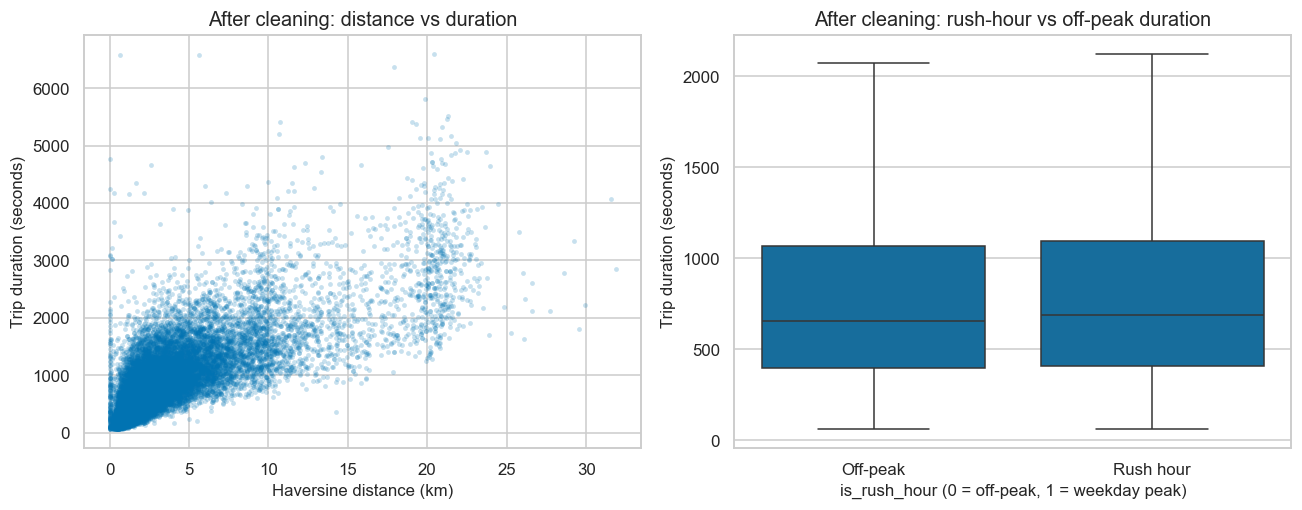

In [139]:
progress("Cluster E", "plot: cleaned distance vs duration")
plot_fe = take_plot_sample(df_fe)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.scatterplot(
    data=plot_fe,
    x="trip_distance_km",
    y="trip_duration",
    s=10,
    alpha=0.22,
    ax=axes[0],
    linewidth=0,
)
axes[0].set_title("After cleaning: distance vs duration")
axes[0].set_xlabel("Haversine distance (km)")
axes[0].set_ylabel("Trip duration (seconds)")

sns.boxplot(
    data=plot_fe,
    x="is_rush_hour",
    y="trip_duration",
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("After cleaning: rush-hour vs off-peak duration")
axes[1].set_xlabel("is_rush_hour (0 = off-peak, 1 = weekday peak)")
axes[1].set_ylabel("Trip duration (seconds)")
axes[1].set_xticks([0, 1], ["Off-peak", "Rush hour"])

finalise(fig)


**Reading this plot.** After cleaning, distance vs duration is a tight upward band (not a spray of impossible points). Rush-hour trips sit higher in the boxplot.


---
# Cluster F : Split, encode, and scale

**Input:** `df_fe`.  
**Output:** numeric matrices `X_train_p` / `X_test_p` and labels `y_train` / `y_test`.

This is the last time we touch pandas columns. All ten models in Cluster G use **these same arrays**.


### F1. How the split is made

- **80% train / 20% test**, `random_state=42`.
- Regression has no class labels, so we bin `trip_duration` into 10 quantile buckets and **stratify on those buckets**. That keeps long trips in both sides.
- `vendor_id` and `store_and_fwd_flag` are one-hot encoded (names, not ordered numbers).
- Every numeric column is put on a StandardScaler. Trees do not need this; SVR and KNN do. We scale **once** so the comparison stays fair.
- The scaler/encoder is **fit on X_train only**, then applied to X_test.
- If the test split is larger than 50,000 rows, we score everyone on the **same 50,000-row slice** so SVR/KNN prediction stays realistic on a laptop.


In [140]:
progress("Cluster F", "80/20 stratified split")
TARGET = "trip_duration"
y = df_fe[TARGET]
X = df_fe.drop(columns=[TARGET])

y_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_bins,
)

print(f"X_train {X_train.shape}  |  X_test {X_test.shape}")
print(f"y_train mean={y_train.mean():.1f}s  median={y_train.median():.1f}s")
print(f"y_test  mean={y_test.mean():.1f}s  median={y_test.median():.1f}s")


[13:21:16] Cluster F  |  80/20 stratified split


[13:21:16] Cluster F  |  80/20 stratified split


X_train (279264, 15)  |  X_test (69816, 15)
y_train mean=838.3s  median=664.0s
y_test  mean=836.7s  median=663.5s


In [141]:
progress("Cluster F", "fit scaler/encoder on TRAIN only")
categorical_features = ["vendor_id", "store_and_fwd_flag"]
numeric_features = [c for c in X_train.columns if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ],
    remainder="drop",
)

X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)
feature_names = preprocess.get_feature_names_out()

# Cap the evaluation set so SVR / KNN prediction stays tractable.
# The subset is drawn once and reused by every model (still a held-out test sample).
if len(X_test_p) > EVAL_TEST_SIZE:
    rng = np.random.RandomState(RANDOM_STATE)
    eval_idx = rng.choice(len(X_test_p), size=EVAL_TEST_SIZE, replace=False)
    X_test_p = X_test_p[eval_idx]
    y_test = y_test.iloc[eval_idx].reset_index(drop=True)
    print(
        f"Evaluation test set capped at {EVAL_TEST_SIZE:,} rows "
        f"(same rows for all 10 models)."
    )
else:
    y_test = y_test.reset_index(drop=True)

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features: {categorical_features}")
print(f"Processed matrix: train {X_train_p.shape}  test {X_test_p.shape}")
print("First processed feature names:")
print(list(feature_names))


[13:21:16] Cluster F  |  fit scaler/encoder on TRAIN only


[13:21:16] Cluster F  |  fit scaler/encoder on TRAIN only


Evaluation test set capped at 50,000 rows (same rows for all 10 models).
Numeric features (13): ['passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_distance_km', 'manhattan_distance_km', 'bearing_deg', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'is_rush_hour']
Categorical features: ['vendor_id', 'store_and_fwd_flag']
Processed matrix: train (279264, 17)  test (50000, 17)
First processed feature names:
['num__passenger_count', 'num__pickup_longitude', 'num__pickup_latitude', 'num__dropoff_longitude', 'num__dropoff_latitude', 'num__trip_distance_km', 'num__manhattan_distance_km', 'num__bearing_deg', 'num__pickup_hour', 'num__pickup_dayofweek', 'num__pickup_month', 'num__is_weekend', 'num__is_rush_hour', 'cat__vendor_id_1', 'cat__vendor_id_2', 'cat__store_and_fwd_flag_N', 'cat__store_and_fwd_flag_Y']


---
# Cluster G : Ten regression models

**Input:** `X_train_p`, `y_train`, shared `X_test_p`, `y_test`.  
**Output:** one row per model in `leaderboard`, plus stored predictions.

Each algorithm has its own fit cell (rubric C1). A helper only **scores** them and it does not hide training in one giant loop. Immediately after each fit the cell prints **R², RMSE, MAE, and 5-fold CV R²** — the four mandatory metrics.

We also record a **mean baseline** (always predict the training average). Its R² is about 0. Everything else must beat it.

Predictions below 1 second are clipped to 1 : a negative duration cannot happen. That clip is applied at prediction time, not during training.


### G0. Scoring helper

`evaluate(name, model, X_tr, y_tr)` fits one algorithm, scores it on the **shared test set**, then runs **5-fold CV R²** on the same training rows that model was allowed to see.

After every algorithm you should see all four mandatory numbers:

- test **R²**
- test **RMSE** (seconds)
- test **MAE** (seconds)
- **5-fold CV R²** (mean, std, and the five fold scores)

The rubric only *requires* CV for the two best models (Cluster H4). We still compute it after every fit so each G-cell is self-contained in the viva. After each of the ten official models, `evaluate` also saves a **result PNG** under `results/figures/` (coefficients, feature importance, or predicted vs actual).


In [142]:
progress("Cluster G", "scoring helper + mean baseline")
leaderboard = []
predictions = {}
fitted_models = {}
cv_folds = {}

CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def metrics_dict(name, y_true, y_pred, train_rows, seconds, cv_scores=None):
    row = {
        "Model": name,
        "Train rows": int(train_rows),
        "Test rows": int(len(y_true)),
        "R2": r2_score(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Fit seconds": seconds,
        "CV R2 mean": np.nan,
        "CV R2 std": np.nan,
        "CV folds": "",
    }
    if cv_scores is not None:
        row["CV R2 mean"] = float(np.mean(cv_scores))
        row["CV R2 std"] = float(np.std(cv_scores))
        row["CV folds"] = np.round(cv_scores, 4).tolist()
    return row


def _cv_n_jobs(estimator):
    """Avoid nested oversubscription: forests / HGB already use threads."""
    inner = estimator
    if isinstance(estimator, TransformedTargetRegressor):
        inner = estimator.regressor
    name = type(inner).__name__
    if any(k in name for k in ("Forest", "HistGradient", "GradientBoosting", "Neighbors")):
        return 1
    return -1


def five_fold_r2(estimator, X_tr, y_tr, label):
    progress("5-fold CV", f"{label}  on {len(X_tr):,} train rows")
    scores = cross_val_score(
        clone(estimator),
        X_tr,
        y_tr,
        cv=CV,
        scoring="r2",
        n_jobs=_cv_n_jobs(estimator),
    )
    return scores


def show_mandatory_metrics(name, row):
    """Print R², RMSE, MAE, and 5-fold CV R² after every algorithm."""
    folds = row["CV folds"]
    print()
    print("=" * 68)
    print(f"  {name}  —  mandatory metrics")
    print("=" * 68)
    print(f"  Shared test set   n = {int(row['Test rows']):,}")
    print(f"    R²                    {row['R2']:.4f}")
    print(f"    RMSE                  {row['RMSE']:.1f} seconds")
    print(f"    MAE                   {row['MAE']:.1f} seconds")
    print(f"  5-fold CV R²      n = {int(row['Train rows']):,} train rows")
    print(f"    mean                  {row['CV R2 mean']:.4f}")
    print(f"    std                   {row['CV R2 std']:.4f}")
    print(f"    folds                 {folds}")
    print("=" * 68)
    display(
        pd.DataFrame(
            [
                {
                    "Model": name,
                    "Test R²": row["R2"],
                    "RMSE (s)": row["RMSE"],
                    "MAE (s)": row["MAE"],
                    "5-fold CV R² mean": row["CV R2 mean"],
                    "5-fold CV R² std": row["CV R2 std"],
                }
            ]
        )
        .style.format(
            {
                "Test R²": "{:.4f}",
                "RMSE (s)": "{:,.1f}",
                "MAE (s)": "{:,.1f}",
                "5-fold CV R² mean": "{:.4f}",
                "5-fold CV R² std": "{:.4f}",
            }
        )
        .hide(axis="index")
    )



OFFICIAL_MODELS = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "ElasticNet Regression",
    "Polynomial Regression",
    "Decision Tree Regressor",
    "Random Forest Regressor",
    "Gradient Boosting Regressor",
    "Support Vector Regressor",
    "K-Nearest Neighbors Regressor",
]


def show_all_metrics_table(title="All models — mandatory metrics"):
    """One ranked table: test R², RMSE, MAE, and 5-fold CV R²."""
    frame = (
        pd.DataFrame(leaderboard)
        .sort_values("R2", ascending=False)
        .reset_index(drop=True)
    )
    frame.insert(0, "Rank", frame.index + 1)
    show = frame.loc[
        :,
        [
            c
            for c in [
                "Rank",
                "Model",
                "Train rows",
                "Test rows",
                "R2",
                "RMSE",
                "MAE",
                "CV R2 mean",
                "CV R2 std",
            ]
            if c in frame.columns
        ],
    ].rename(
        columns={
            "R2": "Test R²",
            "RMSE": "RMSE (s)",
            "MAE": "MAE (s)",
            "CV R2 mean": "5-fold CV R² mean",
            "CV R2 std": "5-fold CV R² std",
        }
    )
    print()
    print("=" * 68)
    print(f"  {title}")
    print(f"  Same shared test set for every row. Ranked by test R².")
    print("=" * 68)
    display(
        show.style.format(
            {
                "Train rows": "{:,}",
                "Test rows": "{:,}",
                "Test R²": "{:.4f}",
                "RMSE (s)": "{:,.1f}",
                "MAE (s)": "{:,.1f}",
                "5-fold CV R² mean": "{:.4f}",
                "5-fold CV R² std": "{:.4f}",
            }
        )
        .hide(axis="index")
    )
    return frame


def _unwrap_estimator(model):
    if isinstance(model, TransformedTargetRegressor):
        return model.regressor
    if isinstance(model, Pipeline):
        return model.named_steps.get("lin", list(model.named_steps.values())[-1])
    return model


def plot_model_result(name, model, y_pred, y_true=None, row=None):
    """One PNG per algorithm: diagnostic plot on top, mandatory metrics table below."""
    y_true_arr = np.asarray(y_test if y_true is None else y_true)
    inner = _unwrap_estimator(model)
    color = sns.color_palette("colorblind")[0]
    coef = getattr(inner, "coef_", None)
    imp = getattr(inner, "feature_importances_", None)
    names = np.asarray(feature_names)

    fig = plt.figure(figsize=(10.5, 7.2))
    gs = fig.add_gridspec(2, 1, height_ratios=[3.6, 1.0], hspace=0.38)
    ax = fig.add_subplot(gs[0])
    ax_table = fig.add_subplot(gs[1])
    ax_table.axis("off")

    if coef is not None and np.ndim(coef) == 1 and len(coef) == len(names):
        series = pd.Series(coef, index=names).sort_values(key=np.abs)
        series.tail(12).plot(kind="barh", ax=ax, color=color)
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title(f"{name} — coefficients")
        ax.set_xlabel("Coefficient (seconds per 1 SD of the feature)")
    elif imp is not None and len(np.asarray(imp)) == len(names):
        series = pd.Series(np.asarray(imp), index=names).sort_values()
        series.tail(12).plot(kind="barh", ax=ax, color=color)
        ax.set_title(f"{name} — feature importance")
        ax.set_xlabel("Importance")
    else:
        rng = np.random.default_rng(RANDOM_STATE)
        n = min(8_000, len(y_true_arr))
        idx = rng.choice(len(y_true_arr), size=n, replace=False)
        ax.scatter(y_true_arr[idx], y_pred[idx], alpha=0.18, s=8, color=color)
        lo = float(min(y_true_arr[idx].min(), y_pred[idx].min()))
        hi = float(max(y_true_arr[idx].max(), y_pred[idx].max()))
        ax.plot([lo, hi], [lo, hi], color="black", lw=1)
        ax.set_xlabel("Actual duration (seconds)")
        ax.set_ylabel("Predicted duration (seconds)")
        ax.set_title(f"{name} — predicted vs actual")

    metrics = row or {}
    col_labels = [
        "Model",
        "Test R²",
        "RMSE (s)",
        "MAE (s)",
        "5-fold CV R² mean",
        "5-fold CV R² std",
    ]
    cell_text = [
        [
            name,
            f"{metrics.get('R2', float('nan')):.4f}",
            f"{metrics.get('RMSE', float('nan')):.1f}",
            f"{metrics.get('MAE', float('nan')):.1f}",
            f"{metrics.get('CV R2 mean', float('nan')):.4f}",
            f"{metrics.get('CV R2 std', float('nan')):.4f}",
        ]
    ]
    table = ax_table.table(
        cellText=cell_text,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.85)
    for (row_i, col_i), cell in table.get_celld().items():
        cell.set_edgecolor("#c5c5c5")
        if row_i == 0:
            cell.set_facecolor("#2f2f2f")
            cell.set_text_props(color="white", weight="bold")
        else:
            cell.set_facecolor("#f4f4f4")
    ax_table.set_title("Mandatory metrics (shared test set)", fontsize=11, pad=8)

    finalise(fig, name=f"{name} result")


def evaluate(name, model, X_tr, y_tr, X_te=X_test_p, y_te=y_test, store=True):
    progress("fitting", f"{name}  on {len(X_tr):,} rows")
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    fit_s = time.perf_counter() - t0
    y_pred = np.clip(model.predict(X_te), 1, None)
    scores = five_fold_r2(model, X_tr, y_tr, name)
    row = metrics_dict(name, y_te, y_pred, len(X_tr), fit_s, scores)
    progress(
        "done",
        f"{name}  R2={row['R2']:.4f}  RMSE={row['RMSE']:.1f}s  MAE={row['MAE']:.1f}s  "
        f"CV R2={row['CV R2 mean']:.4f}±{row['CV R2 std']:.4f}  ({fit_s:.1f}s)",
    )
    if store:
        leaderboard.append(row)
        predictions[name] = y_pred
        fitted_models[name] = model
        cv_folds[name] = scores
        plot_model_result(name, model, y_pred, y_te, row=row)
    show_mandatory_metrics(name, row)
    return model, y_pred, row


# Mean baseline (R2 will be ~0). Same four metrics as every other model.
t0 = time.perf_counter()
y_mean = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_p, y_train)
base_scores = five_fold_r2(dummy, X_train_p, y_train, "Mean baseline")
base_row = metrics_dict(
    "Mean baseline", y_test, y_mean, len(y_train), time.perf_counter() - t0, base_scores
)
leaderboard.append(base_row)
predictions["Mean baseline"] = y_mean
fitted_models["Mean baseline"] = dummy
cv_folds["Mean baseline"] = base_scores
show_mandatory_metrics("Mean baseline", base_row)


[13:21:16] Cluster G  |  scoring helper + mean baseline


[13:21:16] Cluster G  |  scoring helper + mean baseline


[13:21:16] 5-fold CV  |  Mean baseline  on 279,264 train rows


[13:21:16] 5-fold CV  |  Mean baseline  on 279,264 train rows



  Mean baseline  —  mandatory metrics
  Shared test set   n = 50,000
    R²                    -0.0000
    RMSE                  645.5 seconds
    MAE                   462.4 seconds
  5-fold CV R²      n = 279,264 train rows
    mean                  -0.0000
    std                   0.0000
    folds                 [-0.0, -0.0, -0.0, -0.0, -0.0]


Model,Test R²,RMSE (s),MAE (s),5-fold CV R² mean,5-fold CV R² std
Mean baseline,-0.0000,645.5,462.4,-0.0000,0.0000


In [143]:
def subset_train(max_rows, seed=RANDOM_STATE):
    """Reproducible subset of the processed training matrix."""
    n = min(max_rows, len(X_train_p))
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X_train_p), size=n, replace=False)
    if hasattr(X_train_p, "iloc"):
        return X_train_p.iloc[idx], y_train.iloc[idx]
    y_sub = y_train.to_numpy()[idx]
    return X_train_p[idx], y_sub


### G — Model-by-model

Same preprocessed data. Same test rows. Separate Markdown + fit for each algorithm so you can explain any one of them in the viva.

After **each** G-cell, the four mandatory metrics print as a table: test R², RMSE, MAE, and 5-fold CV R².


### G1. Linear Regression (baseline)

Straight line through the features. No penalty. Because features are scaled, a coefficient of +200 on distance means “one extra standard deviation of distance adds about 200 seconds.” This is the model the others have to beat.


[13:21:18] Cluster G  |  Linear Regression


[13:21:18] Cluster G  |  Linear Regression


[13:21:18] fitting  |  Linear Regression  on 279,264 rows


[13:21:18] fitting  |  Linear Regression  on 279,264 rows


[13:21:18] 5-fold CV  |  Linear Regression  on 279,264 train rows


[13:21:18] 5-fold CV  |  Linear Regression  on 279,264 train rows


[13:21:19] done  |  Linear Regression  R2=0.6241  RMSE=395.8s  MAE=273.0s  CV R2=0.6208±0.0039  (0.1s)


[13:21:19] done  |  Linear Regression  R2=0.6241  RMSE=395.8s  MAE=273.0s  CV R2=0.6208±0.0039  (0.1s)
/var/folders/7m/c97hn4813qz83k1lxkkbhfmr0000gn/T/ipykernel_65446/1314929531.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


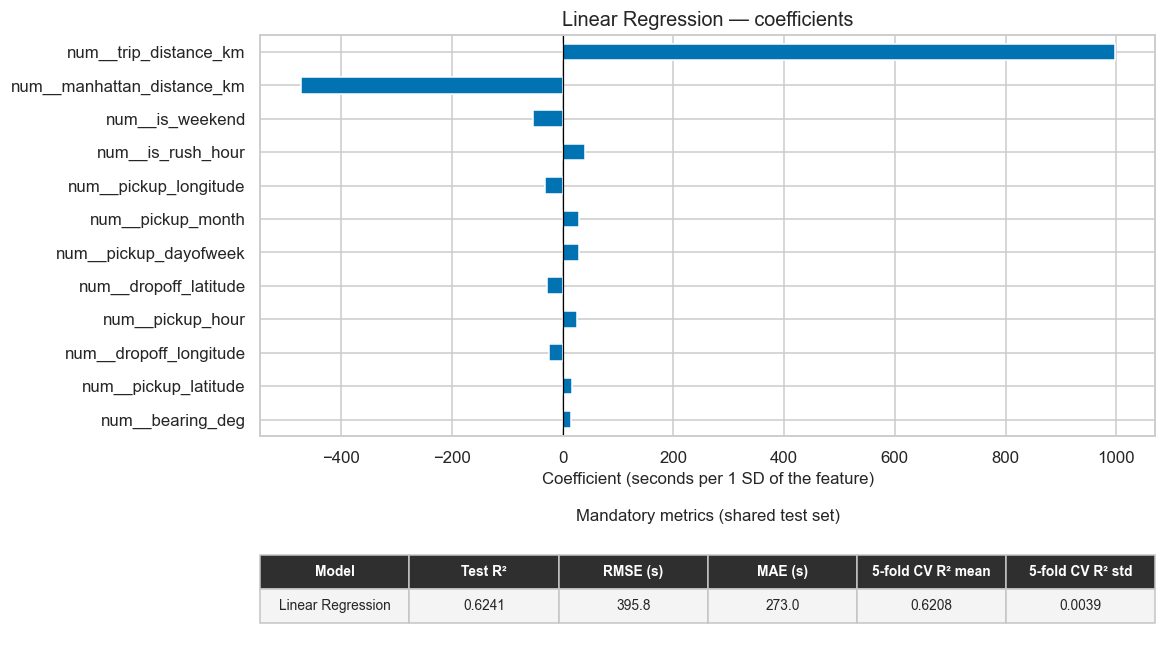


  Linear Regression  —  mandatory metrics
  Shared test set   n = 50,000
    R²                    0.6241
    RMSE                  395.8 seconds
    MAE                   273.0 seconds
  5-fold CV R²      n = 279,264 train rows
    mean                  0.6208
    std                   0.0039
    folds                 [0.6248, 0.6149, 0.6251, 0.6182, 0.6211]


Model,Test R²,RMSE (s),MAE (s),5-fold CV R² mean,5-fold CV R² std
Linear Regression,0.6241,395.8,273.0,0.6208,0.0039



Largest |coefficients| (scaled features):


,coefficient
num__trip_distance_km,997.0044
num__manhattan_distance_km,-472.5426
num__is_weekend,-53.2013
num__is_rush_hour,40.8359
num__pickup_longitude,-31.7612
num__pickup_month,30.0247
num__pickup_dayofweek,29.3775
num__dropoff_latitude,-28.6815
num__pickup_hour,26.0825
num__dropoff_longitude,-24.4456


Intercept (seconds at mean scaled features): 851.6


In [144]:
progress("Cluster G", "Linear Regression")
lin = LinearRegression()
lin, y_pred_lin, _ = evaluate("Linear Regression", lin, X_train_p, y_train)

coef_lin = (
    pd.Series(lin.coef_, index=feature_names)
    .sort_values(key=np.abs, ascending=False)
    .to_frame("coefficient")
)
print("\nLargest |coefficients| (scaled features):")
display(coef_lin.head(12))
print(f"Intercept (seconds at mean scaled features): {lin.intercept_:,.1f}")


**What to look for.** Distance should be the largest coefficient. Haversine and Manhattan distance are collinear, so they may share credit (one can even look negative). That is normal — Ridge is next. Hour / rush-hour should be smaller than distance but not zero. If `store_and_fwd_flag` outranks kilometres, something is wrong.


### G2. Ridge Regression (L2)

Ridge keeps every feature but **shrinks** large weights. Helpful when two distance columns tell the same story. `alpha=1.0` for now; Cluster H searches a grid of `alpha` values.


[13:21:19] Cluster G  |  Ridge


[13:21:19] Cluster G  |  Ridge


[13:21:19] fitting  |  Ridge Regression  on 279,264 rows


[13:21:19] fitting  |  Ridge Regression  on 279,264 rows


[13:21:19] 5-fold CV  |  Ridge Regression  on 279,264 train rows


[13:21:19] 5-fold CV  |  Ridge Regression  on 279,264 train rows


[13:21:20] done  |  Ridge Regression  R2=0.6241  RMSE=395.8s  MAE=273.0s  CV R2=0.6208±0.0039  (0.0s)


[13:21:20] done  |  Ridge Regression  R2=0.6241  RMSE=395.8s  MAE=273.0s  CV R2=0.6208±0.0039  (0.0s)
/var/folders/7m/c97hn4813qz83k1lxkkbhfmr0000gn/T/ipykernel_65446/1314929531.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


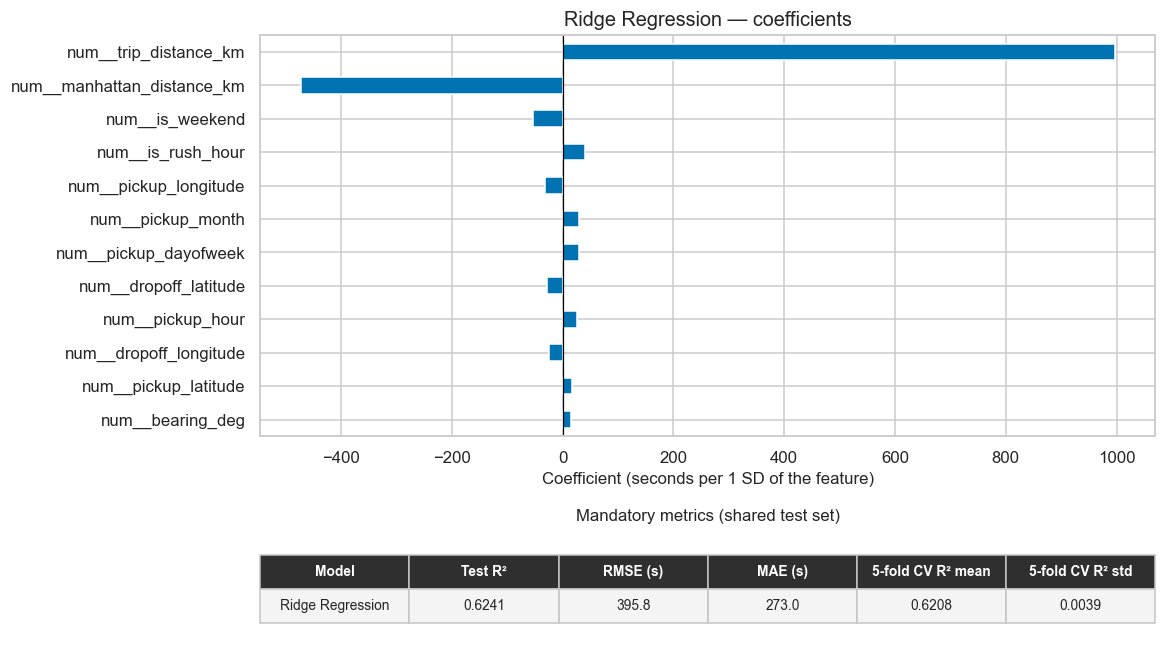


  Ridge Regression  —  mandatory metrics
  Shared test set   n = 50,000
    R²                    0.6241
    RMSE                  395.8 seconds
    MAE                   273.0 seconds
  5-fold CV R²      n = 279,264 train rows
    mean                  0.6208
    std                   0.0039
    folds                 [0.6248, 0.6149, 0.6251, 0.6182, 0.6211]


Model,Test R²,RMSE (s),MAE (s),5-fold CV R² mean,5-fold CV R² std
Ridge Regression,0.6241,395.8,273.0,0.6208,0.0039



Ridge vs Linear: mean |coefficient|
  Linear 105.773
  Ridge  105.720


In [145]:
progress("Cluster G", "Ridge")
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge, _, _ = evaluate("Ridge Regression", ridge, X_train_p, y_train)

coef_ridge = pd.Series(ridge.coef_, index=feature_names)
print("\nRidge vs Linear: mean |coefficient|")
print(f"  Linear {np.mean(np.abs(lin.coef_)):.3f}")
print(f"  Ridge  {np.mean(np.abs(ridge.coef_)):.3f}")


### G3. Lasso Regression (L1)

Lasso can set some weights to **exactly 0** (automatic feature drop). We expect it to keep distance and drop the weakest extras. If every weight is 0, `alpha` is too big. If none are 0, `alpha` is too small.


[13:21:21] Cluster G  |  Lasso — can take a bit


[13:21:21] Cluster G  |  Lasso — can take a bit


[13:21:21] fitting  |  Lasso Regression  on 279,264 rows


[13:21:21] fitting  |  Lasso Regression  on 279,264 rows


[13:21:22] 5-fold CV  |  Lasso Regression  on 279,264 train rows


[13:21:22] 5-fold CV  |  Lasso Regression  on 279,264 train rows


[13:21:25] done  |  Lasso Regression  R2=0.6240  RMSE=395.8s  MAE=273.2s  CV R2=0.6206±0.0040  (1.7s)


[13:21:25] done  |  Lasso Regression  R2=0.6240  RMSE=395.8s  MAE=273.2s  CV R2=0.6206±0.0040  (1.7s)
/var/folders/7m/c97hn4813qz83k1lxkkbhfmr0000gn/T/ipykernel_65446/1314929531.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


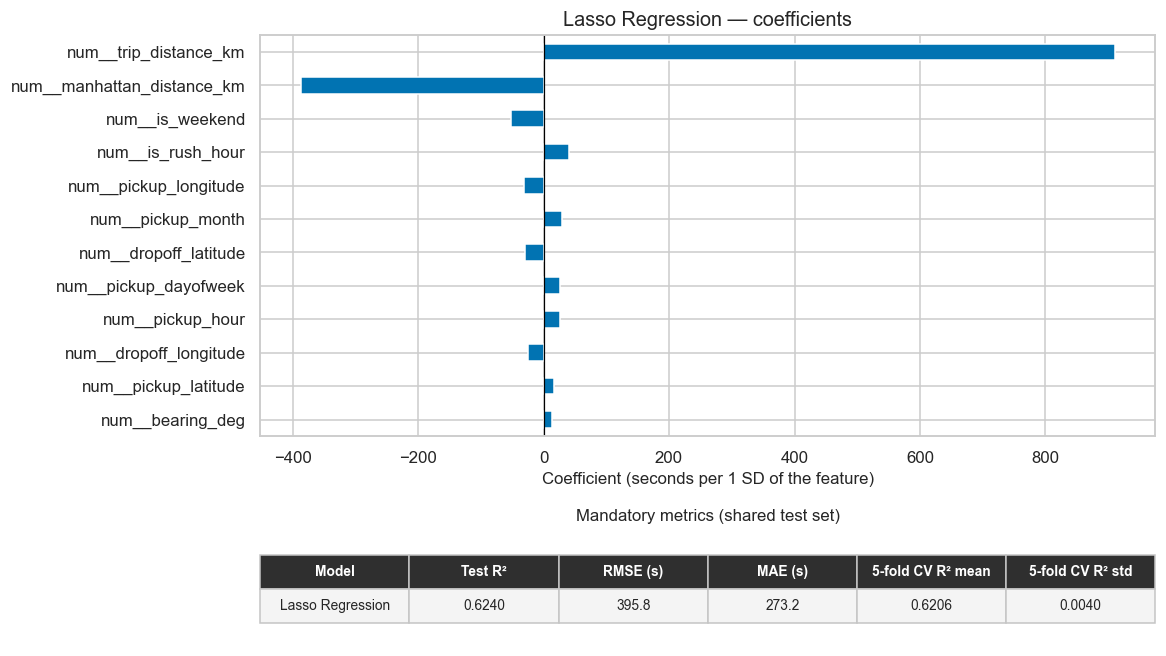


  Lasso Regression  —  mandatory metrics
  Shared test set   n = 50,000
    R²                    0.6240
    RMSE                  395.8 seconds
    MAE                   273.2 seconds
  5-fold CV R²      n = 279,264 train rows
    mean                  0.6206
    std                   0.0040
    folds                 [0.6248, 0.6145, 0.6249, 0.6179, 0.6209]


Model,Test R²,RMSE (s),MAE (s),5-fold CV R² mean,5-fold CV R² std
Lasso Regression,0.6240,395.8,273.2,0.6206,0.0040



Lasso zeros out 4 / 17 features (23.5%)
Non-zero coefficients:


,coefficient
num__trip_distance_km,910.2990
num__manhattan_distance_km,-386.5769
num__is_weekend,-51.1492
num__is_rush_hour,40.1527
num__pickup_longitude,-30.6032
num__pickup_month,29.5169
num__dropoff_latitude,-29.3265
num__pickup_dayofweek,27.0577
num__pickup_hour,25.4877
num__dropoff_longitude,-24.0586


In [146]:
progress("Cluster G", "Lasso — can take a bit")
lasso = Lasso(alpha=0.5, max_iter=20000, random_state=RANDOM_STATE)
lasso, _, _ = evaluate("Lasso Regression", lasso, X_train_p, y_train)

lasso_coef = pd.Series(lasso.coef_, index=feature_names)
n_zero = int((np.abs(lasso_coef) < 1e-10).sum())
print(f"\nLasso zeros out {n_zero} / {len(lasso_coef)} features ({100 * n_zero / len(lasso_coef):.1f}%)")
print("Non-zero coefficients:")
display(
    lasso_coef[np.abs(lasso_coef) >= 1e-10]
    .sort_values(key=np.abs, ascending=False)
    .to_frame("coefficient")
)


### G4. ElasticNet (L1 + L2)

Half Lasso, half Ridge (`l1_ratio=0.5`). We want Lasso’s sparsity **and** Ridge’s stability on the two distance columns.


[13:21:25] Cluster G  |  ElasticNet


[13:21:25] Cluster G  |  ElasticNet


[13:21:25] fitting  |  ElasticNet Regression  on 279,264 rows


[13:21:25] fitting  |  ElasticNet Regression  on 279,264 rows


[13:21:25] 5-fold CV  |  ElasticNet Regression  on 279,264 train rows


[13:21:25] 5-fold CV  |  ElasticNet Regression  on 279,264 train rows


[13:21:27] done  |  ElasticNet Regression  R2=0.6092  RMSE=403.5s  MAE=281.6s  CV R2=0.6047±0.0039  (0.1s)


[13:21:27] done  |  ElasticNet Regression  R2=0.6092  RMSE=403.5s  MAE=281.6s  CV R2=0.6047±0.0039  (0.1s)
/var/folders/7m/c97hn4813qz83k1lxkkbhfmr0000gn/T/ipykernel_65446/1314929531.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


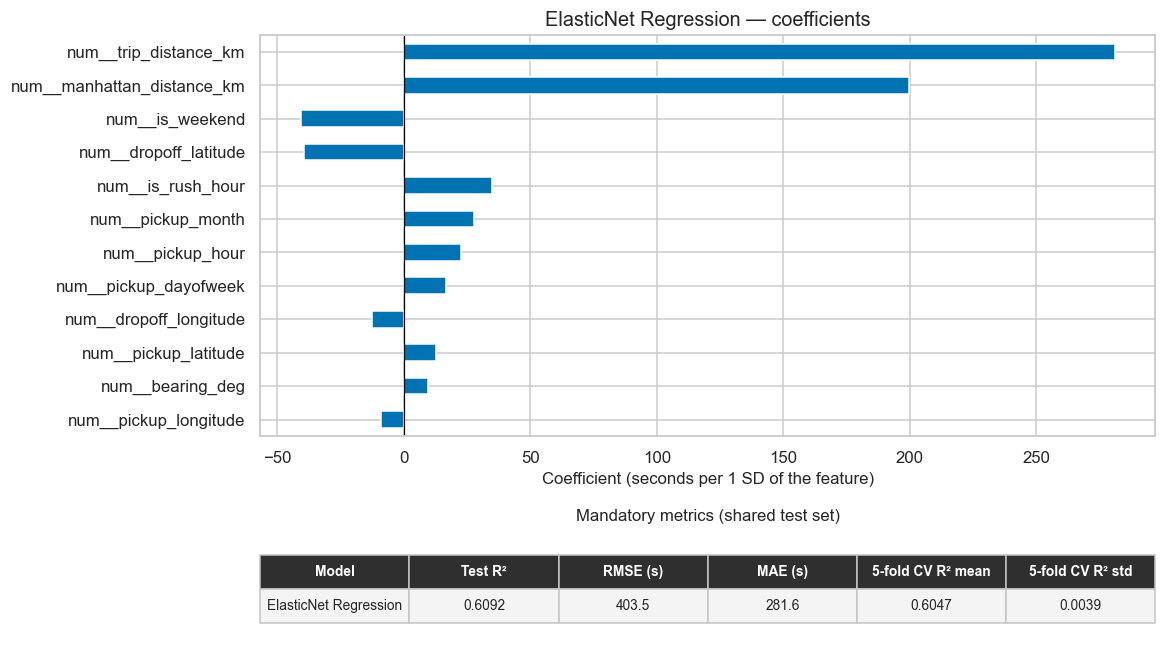


  ElasticNet Regression  —  mandatory metrics
  Shared test set   n = 50,000
    R²                    0.6092
    RMSE                  403.5 seconds
    MAE                   281.6 seconds
  5-fold CV R²      n = 279,264 train rows
    mean                  0.6047
    std                   0.0039
    folds                 [0.6092, 0.5989, 0.6083, 0.602, 0.6052]


Model,Test R²,RMSE (s),MAE (s),5-fold CV R² mean,5-fold CV R² std
ElasticNet Regression,0.6092,403.5,281.6,0.6047,0.0039


In [147]:
progress("Cluster G", "ElasticNet")
enet = ElasticNet(alpha=0.2, l1_ratio=0.5, max_iter=20000, random_state=RANDOM_STATE)
enet, _, _ = evaluate("ElasticNet Regression", enet, X_train_p, y_train)


### G5. Polynomial Regression

We expand features with `PolynomialFeatures`, then fit Linear Regression. Degree 1 is the ordinary linear model. Degree 2 lets distance interact with hour (the congestion pattern from EDA). We do **not** try degree 3 — too many columns, easy to overfit. The leaderboard keeps whichever of degree 1 or 2 scores better on the shared test set.


[13:21:27] Cluster G  |  Polynomial degree 1 vs 2


[13:21:27] Cluster G  |  Polynomial degree 1 vs 2


[13:21:27] fitting  |  Polynomial (degree 1)  on 279,264 rows


[13:21:27] fitting  |  Polynomial (degree 1)  on 279,264 rows


[13:21:27] 5-fold CV  |  Polynomial (degree 1)  on 279,264 train rows


...

[13:21:34] done  |  Polynomial (degree 2)  R2=0.7026  RMSE=352.1s  MAE=238.6s  CV R2=0.6958±0.0040  (1.8s)



  Polynomial (degree 2)  —  mandatory metrics
  Shared test set   n = 50,000
    R²                    0.7026
    RMSE                  352.1 seconds
    MAE                   238.6 seconds
  5-fold CV R²      n = 279,264 train rows
    mean                  0.6958
    std                   0.0040
    folds                 [0.6995, 0.6884, 0.6992, 0.6963, 0.6956]


Model,Test R²,RMSE (s),MAE (s),5-fold CV R² mean,5-fold CV R² std
Polynomial (degree 2),0.7026,352.1,238.6,0.6958,0.0040


,Model,Train rows,Test rows,R2,RMSE,MAE,Fit seconds,CV R2 mean,CV R2 std,CV folds,Expanded features
0,Polynomial (degree 1),279264,50000,0.6241,395.7913,273.0072,0.0743,0.6208,0.0039,"[0.6248, 0.6149, 0.6251, 0.6182, 0.6211]",17
1,Polynomial (degree 2),279264,50000,0.7026,352.0505,238.5700,1.7594,0.6958,0.0040,"[0.6995, 0.6884, 0.6992, 0.6963, 0.6956]",170


/var/folders/7m/c97hn4813qz83k1lxkkbhfmr0000gn/T/ipykernel_65446/1314929531.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


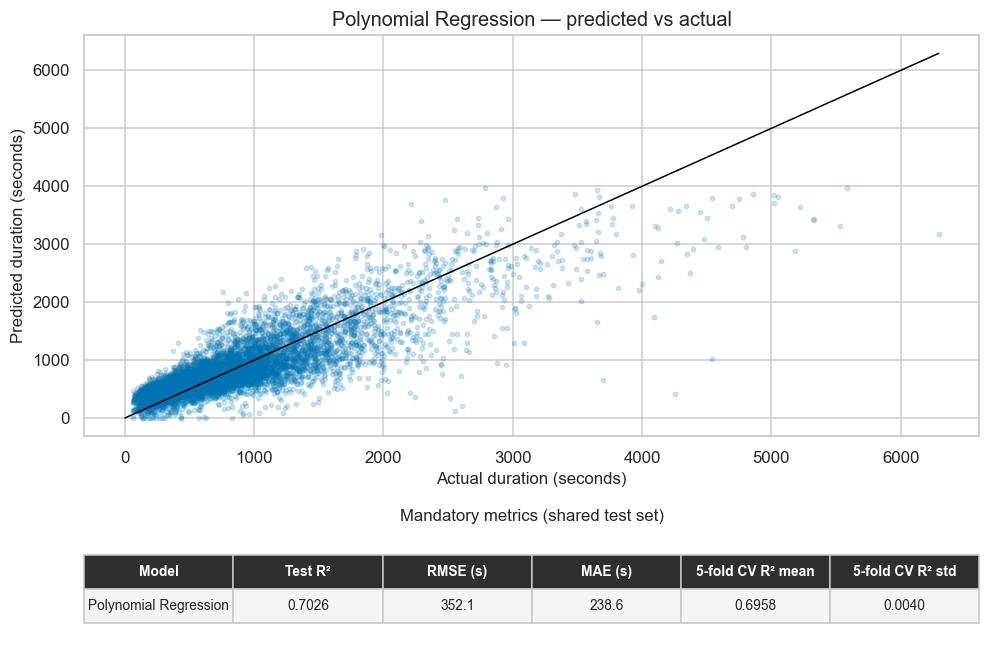


Leaderboard entry: Polynomial Regression (degree 2)
Mandatory metrics for the official polynomial model are the degree-2 numbers printed above.


In [148]:
progress("Cluster G", "Polynomial degree 1 vs 2")
poly_comparison = []
poly_models = {}
for degree in (1, 2):
    pipe = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("lin", LinearRegression()),
        ]
    )
    pipe, y_pred, row = evaluate(
        f"Polynomial (degree {degree})",
        pipe,
        X_train_p,
        y_train,
        store=False,
    )
    n_features = pipe.named_steps["poly"].n_output_features_
    row = dict(row)
    row["Expanded features"] = n_features
    poly_comparison.append(row)
    poly_models[degree] = (pipe, y_pred, row)

poly_table = pd.DataFrame(poly_comparison)
display(poly_table)

best_degree = int(poly_table.loc[poly_table["R2"].idxmax(), "Model"].split()[-1].strip(")"))
best_pipe, best_poly_pred, best_row = poly_models[best_degree]
official_row = dict(best_row)
official_row["Model"] = "Polynomial Regression"
leaderboard.append(official_row)
predictions["Polynomial Regression"] = best_poly_pred
fitted_models["Polynomial Regression"] = best_pipe
folds = official_row.get("CV folds")
if folds is not None and not (isinstance(folds, str) and folds == ""):
    cv_folds["Polynomial Regression"] = np.asarray(folds, dtype=float)
plot_model_result("Polynomial Regression", best_pipe, best_poly_pred, row=official_row)
print(f"\nLeaderboard entry: Polynomial Regression (degree {best_degree})")
print("Mandatory metrics for the official polynomial model are the degree-"
      f"{best_degree} numbers printed above.")


### G6. Decision Tree

The tree splits the data with yes/no questions (distance > 5 km? hour > 16?). That captures interactions without a polynomial expansion. `max_depth=12` and `min_samples_leaf=50` stop it memorising noise. Feature importance is required by the rubric.


[13:21:34] Cluster G  |  Decision Tree


[13:21:34] Cluster G  |  Decision Tree


[13:21:34] fitting  |  Decision Tree Regressor  on 279,264 rows


[13:21:34] fitting  |  Decision Tree Regressor  on 279,264 rows


[13:21:36] 5-fold CV  |  Decision Tree Regressor  on 279,264 train rows


[13:21:36] 5-fold CV  |  Decision Tree Regressor  on 279,264 train rows


[13:21:38] done  |  Decision Tree Regressor  R2=0.7506  RMSE=322.4s  MAE=211.5s  CV R2=0.7451±0.0025  (2.0s)


[13:21:38] done  |  Decision Tree Regressor  R2=0.7506  RMSE=322.4s  MAE=211.5s  CV R2=0.7451±0.0025  (2.0s)
/var/folders/7m/c97hn4813qz83k1lxkkbhfmr0000gn/T/ipykernel_65446/1314929531.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


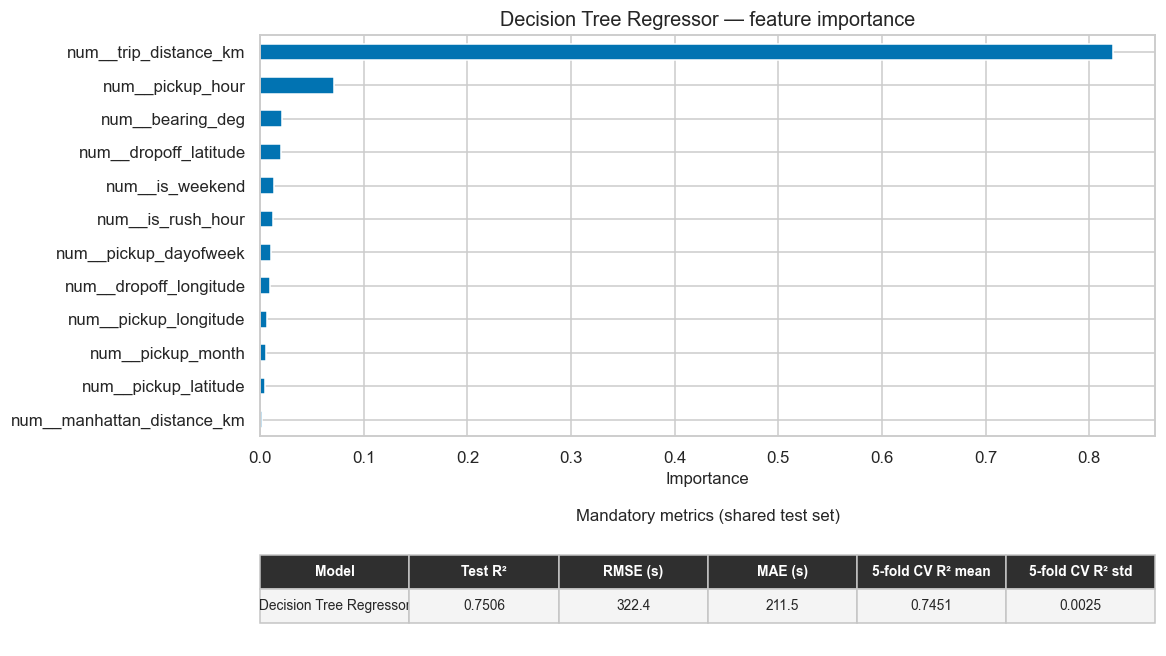


  Decision Tree Regressor  —  mandatory metrics
  Shared test set   n = 50,000
    R²                    0.7506
    RMSE                  322.4 seconds
    MAE                   211.5 seconds
  5-fold CV R²      n = 279,264 train rows
    mean                  0.7451
    std                   0.0025
    folds                 [0.7475, 0.7404, 0.7467, 0.7453, 0.7458]


Model,Test R²,RMSE (s),MAE (s),5-fold CV R² mean,5-fold CV R² std
Decision Tree Regressor,0.7506,322.4,211.5,0.7451,0.0025


,importance
num__trip_distance_km,0.8228
num__pickup_hour,0.0714
num__bearing_deg,0.0214
num__dropoff_latitude,0.0203
num__is_weekend,0.0133
num__is_rush_hour,0.0125
num__pickup_dayofweek,0.0103
num__dropoff_longitude,0.0094
num__pickup_longitude,0.0066
num__pickup_month,0.0053


In [149]:
progress("Cluster G", "Decision Tree")
tree = DecisionTreeRegressor(
    max_depth=12,
    min_samples_leaf=50,
    random_state=RANDOM_STATE,
)
tree, _, _ = evaluate("Decision Tree Regressor", tree, X_train_p, y_train)

tree_imp = (
    pd.Series(tree.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
    .to_frame("importance")
)
display(tree_imp.head(12))


**What to look for.** Distance should be the top split. Then hour, bearing, or coordinates (airports). If passenger count ranks first, the tree is too deep or the features were not processed.


### G7. Random Forest

Many trees, each on a random slice of rows and columns, then average. More stable than one tree. `n_jobs=-1` uses all CPU cores. Cluster H will search `n_estimators` / `max_depth`.


In [ ]:
progress("Cluster G", "Random Forest — slow; watch this cell")
forest = RandomForestRegressor(
    n_estimators=80,
    max_depth=18,
    min_samples_leaf=20,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
)
forest, _, _ = evaluate("Random Forest Regressor", forest, X_train_p, y_train)

forest_imp = (
    pd.Series(forest.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
    .to_frame("importance")
)
display(forest_imp.head(10))


[13:21:38] Cluster G  |  Random Forest — slow; watch this cell


[13:21:38] Cluster G  |  Random Forest — slow; watch this cell


[13:21:38] fitting  |  Random Forest Regressor  on 279,264 rows


[13:21:38] fitting  |  Random Forest Regressor  on 279,264 rows
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    7.9s


[13:21:58] 5-fold CV  |  Random Forest Regressor  on 279,264 train rows


[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:   19.8s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  80 out of  80 | elapsed:    0.1s finished
[13:21:58] 5-fold CV  |  Random Forest Regressor  on 279,264 train rows
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:   14.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  80 out of  80 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.2s


### G8. Gradient Boosting

Trees added one after another, each fixing the previous one’s mistakes. sklearn’s classic `GradientBoostingRegressor` is too slow here, so we use **`HistGradientBoostingRegressor`** — still sklearn, same idea, built for large tables. `learning_rate=0.08`.


[13:05:14] Cluster G  |  Gradient Boosting — prints each iteration


[13:05:14] Cluster G  |  Gradient Boosting — prints each iteration


[13:05:14] fitting  |  Gradient Boosting Regressor  on 279,264 rows


[13:05:14] fitting  |  Gradient Boosting Regressor  on 279,264 rows


Binning 0.034 GB of training data: 0.048 s
Binning 0.004 GB of validation data: 0.003 s
Fitting gradient boosted rounds:
Fit 200 trees in 2.417 s, (6200 total leaves)
Time spent computing histograms: 0.989s
Time spent finding best splits:  0.341s
Time spent applying splits:      0.644s
Time spent predicting:           0.056s
[13:05:16] 5-fold CV  |  Gradient Boosting Regressor  on 279,264 train rows


[13:05:16] 5-fold CV  |  Gradient Boosting Regressor  on 279,264 train rows


Binning 0.027 GB of training data: 0.043 s
Binning 0.003 GB of validation data: 0.002 s
Fitting gradient boosted rounds:
Fit 200 trees in 2.186 s, (6200 total leaves)
Time spent computing histograms: 0.872s
Time spent finding best splits:  0.332s
Time spent applying splits:      0.633s
Time spent predicting:           0.047s
Binning 0.027 GB of training data: 0.042 s
Binning 0.003 GB of validation data: 0.002 s
Fitting gradient boosted rounds:
Fit 200 trees in 2.617 s, (6200 total leaves)
Time spent computing histograms: 0.991s
Time spent finding best splits:  0.392s
Time spent applying splits:      0.730s
Time spent predicting:           0.049s
Binning 0.027 GB of training data: 0.046 s
Binning 0.003 GB of validation data: 0.002 s
Fitting gradient boosted rounds:
Fit 200 trees in 2.377 s, (6200 total leaves)
Time spent computing histograms: 0.943s
Time spent finding best splits:  0.376s
Time spent applying splits:      0.685s
Time spent predicting:           0.048s
Binning 0.027 GB of

Model,Test R²,RMSE (s),MAE (s),5-fold CV R² mean,5-fold CV R² std
Gradient Boosting Regressor,0.7961,291.5,188.8,0.7921,0.0028


[13:05:29] done  |  Gradient Boosting Regressor  R2=0.7961  RMSE=291.5s  MAE=188.8s  CV R2=0.7921±0.0028  (2.4s)


[13:05:29] done  |  Gradient Boosting Regressor  R2=0.7961  RMSE=291.5s  MAE=188.8s  CV R2=0.7921±0.0028  (2.4s)


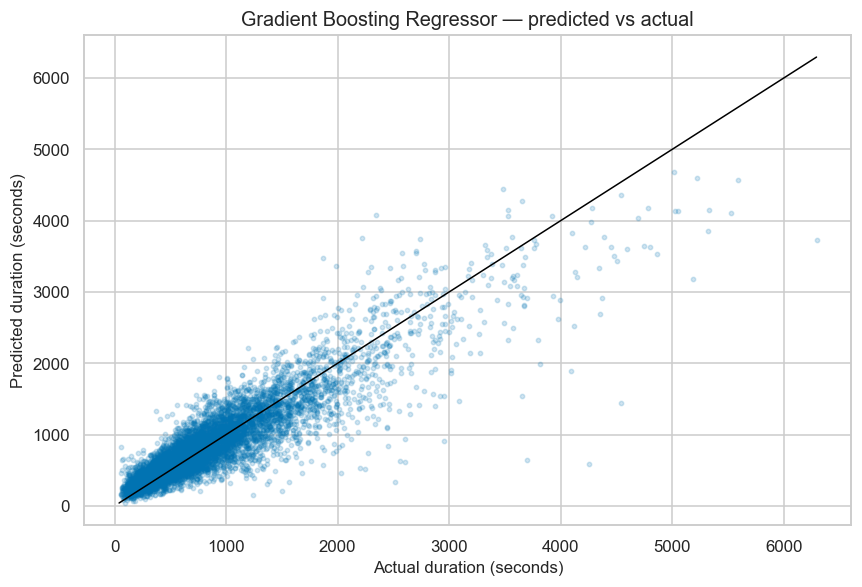

In [ ]:
progress("Cluster G", "Gradient Boosting — prints each iteration")
gbm = HistGradientBoostingRegressor(
    learning_rate=0.08,
    max_depth=6,
    max_iter=200,
    l2_regularization=0.1,
    verbose=1,
    random_state=RANDOM_STATE,
)
gbm, _, _ = evaluate("Gradient Boosting Regressor", gbm, X_train_p, y_train)


### G9. Support Vector Regressor (SVR)

Looks for a “tube” around the points in a high-dimensional space (RBF kernel). Training time grows roughly with *n²*, so we train on **12,000 training rows only**. Features are already scaled. The **target** is scaled too (`TransformedTargetRegressor`) because `C` and `epsilon` assume numbers near 0–1, not 800 seconds. We still **score the same test rows** as everyone else.


In [ ]:
progress("Cluster G", "SVR on 12k rows — slow; watch this cell")
X_svr, y_svr = subset_train(SVR_TRAIN_SIZE)
print(f"SVR training subset: {len(X_svr):,} rows  |  test rows remain {len(X_test_p):,}")

svr = TransformedTargetRegressor(
    regressor=SVR(kernel="rbf", C=1.0, epsilon=0.1, verbose=True),
    transformer=StandardScaler(),
)
svr, _, _ = evaluate("Support Vector Regressor", svr, X_svr, y_svr)


[13:05:29] Cluster G  |  SVR on 12k rows — slow; watch this cell


[13:05:29] Cluster G  |  SVR on 12k rows — slow; watch this cell


SVR training subset: 12,000 rows  |  test rows remain 50,000
[13:05:29] fitting  |  Support Vector Regressor  on 12,000 rows


[13:05:29] fitting  |  Support Vector Regressor  on 12,000 rows


[LibSVM]............*........*
optimization finished, #iter = 20085
obj = -2795.116428, rho = -0.750939
nSV = 8947, nBSV = 8094


**How to talk about SVR.** If it ranks last, that does **not** mean kernels are useless. It means this model saw far fewer trips than the forest. The `Train rows` column in the leaderboard is there so you can say that out loud.


### G10. K-Nearest Neighbors

Predicts the average duration of the *k* closest training trips. `k=15`. Needs scaled features (otherwise longitude would dominate). We train on **40,000 rows** and still score the shared test set. Small *k* = jumpy; large *k* = too smooth.

The last G-cell also prints **one table of all ten models** with test R², RMSE, MAE, and 5-fold CV R².


In [ ]:
progress("Cluster G", "KNN")
X_knn, y_knn = subset_train(KNN_TRAIN_SIZE)
print(f"KNN training subset: {len(X_knn):,} rows")

knn = KNeighborsRegressor(n_neighbors=15, weights="distance", n_jobs=-1)
knn, _, _ = evaluate("K-Nearest Neighbors Regressor", knn, X_knn, y_knn)

print()
progress("Cluster G", "full metrics table — all 10 algorithms")
show_all_metrics_table("Ten regression algorithms + mean baseline")


[09:04:52] Cluster G  |  KNN


[09:04:52] Cluster G  |  KNN


KNN training subset: 40,000 rows
[09:04:52] fitting  |  K-Nearest Neighbors Regressor  on 40,000 rows


[09:04:52] fitting  |  K-Nearest Neighbors Regressor  on 40,000 rows


[09:04:53] done  |  K-Nearest Neighbors Regressor  R2=0.6993  RMSE=354.0s  MAE=243.5s  (0.0s)


[09:04:53] done  |  K-Nearest Neighbors Regressor  R2=0.6993  RMSE=354.0s  MAE=243.5s  (0.0s)


---
# Cluster H : Compare, tune, and check

**Input:** `leaderboard` from Cluster G.  
**Output:** ranked table, tuned Ridge + Random Forest, residual plots, 5-fold CV on the top two official models.


### H1. Comparison table

One table of **all mandatory metrics** for the ten algorithms (plus the mean baseline), same test trips, ranked by test R² (rubric C2). Columns: test R², RMSE, MAE, 5-fold CV R² mean, 5-fold CV R² std. **Train rows** shows that SVR/KNN did not see the full split. The same table is also printed at the end of Cluster G, immediately after the tenth model.


[09:04:53] Cluster H  |  comparison table


[09:04:53] Cluster H  |  comparison table


,Rank,Model,Train rows,R2,RMSE,MAE,Fit seconds
0,1,Gradient Boosting Regressor,"279,264",0.7961,291.5,188.8,3.7
1,2,Random Forest Regressor,"279,264",0.7912,295.0,189.7,24.6
2,3,Decision Tree Regressor,"279,264",0.7506,322.4,211.5,2.2
3,4,Support Vector Regressor,"12,000",0.7281,336.6,213.1,3.2
4,5,Polynomial Regression,"279,264",0.7026,352.1,238.6,2.4
5,6,K-Nearest Neighbors Regressor,"40,000",0.6993,354.0,243.5,0.0
6,7,Ridge Regression,"279,264",0.6241,395.8,273.0,0.0
7,8,Linear Regression,"279,264",0.6241,395.8,273.0,0.1
8,9,Lasso Regression,"279,264",0.6240,395.8,273.2,3.4
9,10,ElasticNet Regression,"279,264",0.6092,403.5,281.6,0.3


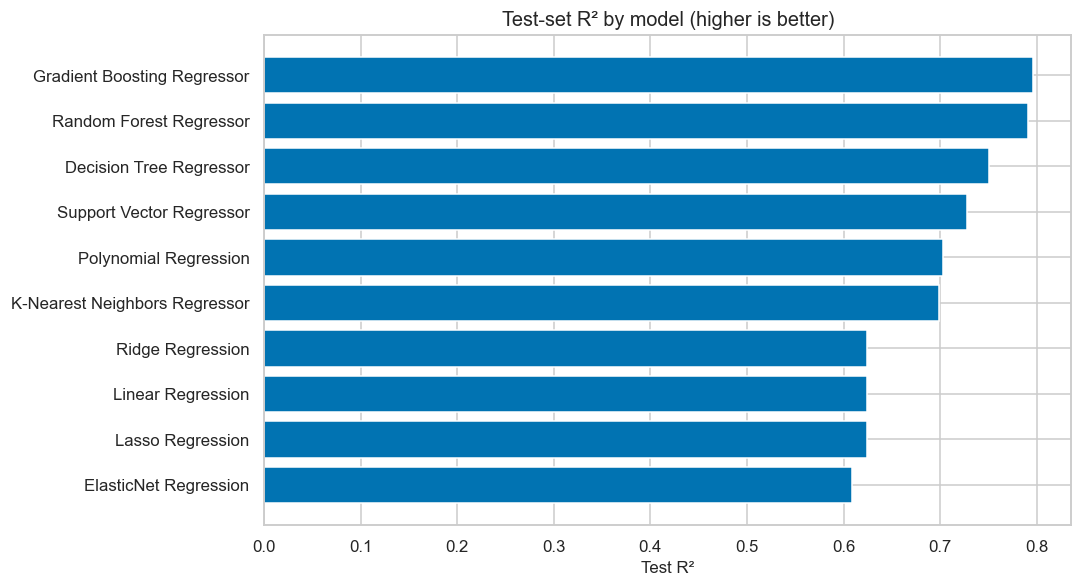

In [ ]:
progress("Cluster H", "comparison table")
results = show_all_metrics_table("Ten regression algorithms + mean baseline")

# Same horizontal bar style for every mandatory metric (exclude mean baseline).
plot_res = results[results["Model"] != "Mean baseline"].copy()
metric_charts = [
    ("R2", "Test R²", "Test-set R² by model (higher is better)", True),
    ("RMSE", "RMSE (seconds)", "Test-set RMSE by model (lower is better)", False),
    ("MAE", "MAE (seconds)", "Test-set MAE by model (lower is better)", False),
    ("CV R2 mean", "5-fold CV R²", "5-fold CV R² by model (higher is better)", True),
]
color = sns.color_palette("colorblind")[0]
for col, xlabel, title, higher_is_better in metric_charts:
    if col not in plot_res.columns:
        continue
    ordered = plot_res.sort_values(col, ascending=higher_is_better)
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.barh(ordered["Model"], ordered[col], color=color)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    finalise(fig)


**How to read it.** Quote R² for ranking. Quote RMSE in minutes (`RMSE / 60`) when you talk to a person. MAE cares less about the remaining long trips. Tree ensembles should lead. Linear models should sit close to each other. SVR is the “small-sample” check. The table also carries **5-fold CV R²** (mean ± std) computed after each G-cell.

The four bar charts use the same layout: best model at the top. For R² / CV R², longer bars are better; for RMSE / MAE, shorter bars are better.


### H2. Hyperparameter tuning

Rubric C3: search **at least two** models and report the gain.

1. **Ridge** — `GridSearchCV` over `alpha` on the full training matrix (cheap).
2. **Random Forest** — `RandomizedSearchCV` on 40k rows, then refit the winner on the full training matrix.


The search cells below print **best parameters** and **test R² before vs after**. Ridge is cheap enough to search on the full training matrix. Forest search uses 40k rows, then the winning settings are refit on all training rows.


In [ ]:
progress("Cluster H", "GridSearchCV Ridge")
ridge_grid = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 250.0, 1000.0]},
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2,
)
ridge_grid.fit(X_train_p, y_train)
print("Ridge best params:", ridge_grid.best_params_)
print(f"Ridge best 5-fold CV R2: {ridge_grid.best_score_:.4f}")

ridge_untuned_r2 = next(r["R2"] for r in leaderboard if r["Model"] == "Ridge Regression")
ridge_tuned, y_ridge_tuned, row_ridge_tuned = evaluate(
    "Ridge Regression (tuned)",
    Ridge(**ridge_grid.best_params_, random_state=RANDOM_STATE),
    X_train_p,
    y_train,
)
print(f"Ridge test R2 before tuning: {ridge_untuned_r2:.4f}")
print(f"Ridge test R2 after tuning:  {row_ridge_tuned['R2']:.4f}")
print(f"Absolute improvement:        {row_ridge_tuned['R2'] - ridge_untuned_r2:+.4f}")


[09:04:53] Cluster H  |  GridSearchCV Ridge


[09:04:53] Cluster H  |  GridSearchCV Ridge


Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ........................................alpha=0.001; total time=   0.2s
[CV] END ..........................................alpha=0.1; total time=   0.2s
[CV] END ........................................alpha=0.001; total time=   0.2s
[CV] END .........................................alpha=0.01; total time=   0.2s
[CV] END ........................................alpha=0.001; total time=   0.2s
[CV] END .........................................alpha=0.01; total time=   0.2s
[CV] END .........................................alpha=0.01; total time=   0.2s
[CV] END ..........................................alpha=0.1; total time=   0.2s
[CV] END ........................................alpha=0.001; total time=   0.2s
[CV] END .........................................alpha=0.01; total time=   0.3s
[CV] END .........................................alpha=0.01; total time=   0.2s
[CV] END ........................................

[09:04:56] fitting  |  Ridge Regression (tuned)  on 279,264 rows


[09:04:56] done  |  Ridge Regression (tuned)  R2=0.6241  RMSE=395.8s  MAE=273.0s  (0.0s)


[09:04:56] done  |  Ridge Regression (tuned)  R2=0.6241  RMSE=395.8s  MAE=273.0s  (0.0s)


Ridge test R2 before tuning: 0.6241
Ridge test R2 after tuning:  0.6241
Absolute improvement:        -0.0000


In [ ]:
progress("Cluster H", "RandomizedSearchCV Random Forest — slow")
X_tune, y_tune = subset_train(TUNE_SAMPLE_SIZE)

forest_search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions={
        "n_estimators": [60, 80, 120],
        "max_depth": [12, 16, 20, None],
        "min_samples_leaf": [10, 20, 40],
        "max_features": ["sqrt", 0.5, 1.0],
    },
    n_iter=8,
    scoring="r2",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
)
forest_search.fit(X_tune, y_tune)
print("Random Forest best params (from 40k search):", forest_search.best_params_)
print(f"Random Forest best 3-fold CV R2 on subset: {forest_search.best_score_:.4f}")

forest_untuned_r2 = next(r["R2"] for r in leaderboard if r["Model"] == "Random Forest Regressor")
forest_tuned, _, row_forest_tuned = evaluate(
    "Random Forest Regressor (tuned)",
    RandomForestRegressor(**forest_search.best_params_, n_jobs=-1, random_state=RANDOM_STATE),
    X_train_p,
    y_train,
)
print(f"Forest test R2 before tuning: {forest_untuned_r2:.4f}")
print(f"Forest test R2 after tuning:  {row_forest_tuned['R2']:.4f}")
print(f"Absolute improvement:         {row_forest_tuned['R2'] - forest_untuned_r2:+.4f}")


[09:04:56] Cluster H  |  RandomizedSearchCV Random Forest — slow


[09:04:56] Cluster H  |  RandomizedSearchCV Random Forest — slow


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=20, n_estimators=80; total time=   3.8s
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=20, n_estimators=80; total time=   3.8s
[CV] END max_depth=12, max_features=sqrt, min_samples_leaf=20, n_estimators=80; total time=   4.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=10, n_estimators=120; total time=   6.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=10, n_estimators=120; total time=   6.6s
[CV] END max_depth=12, max_features=0.5, min_samples_leaf=10, n_estimators=80; total time=   7.1s
[CV] END max_depth=12, max_features=0.5, min_samples_leaf=10, n_estimators=80; total time=   7.2s
[CV] END max_depth=12, max_features=0.5, min_samples_leaf=10, n_estimators=80; total time=   7.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=10, n_estimators=120; total time=   6.8s
[CV] END max_depth=20, max_features=sqrt, m

[09:05:15] fitting  |  Random Forest Regressor (tuned)  on 279,264 rows


[09:05:31] done  |  Random Forest Regressor (tuned)  R2=0.7921  RMSE=294.3s  MAE=189.9s  (16.5s)


[09:05:31] done  |  Random Forest Regressor (tuned)  R2=0.7921  RMSE=294.3s  MAE=189.9s  (16.5s)


Forest test R2 before tuning: 0.7912
Forest test R2 after tuning:  0.7921
Absolute improvement:         +0.0009


In [ ]:
results_tuned = (
    pd.DataFrame(leaderboard)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)
results_tuned.insert(0, "Rank", results_tuned.index + 1)
fmt = {
    "R2": "{:.4f}",
    "RMSE": "{:,.1f}",
    "MAE": "{:,.1f}",
    "Fit seconds": "{:,.1f}",
    "Train rows": "{:,}",
    "Test rows": "{:,}",
    "CV R2 mean": "{:.4f}",
    "CV R2 std": "{:.4f}",
}
display(results_tuned.drop(columns=["CV folds"], errors="ignore").style.format(fmt))


,Rank,Model,Train rows,R2,RMSE,MAE,Fit seconds
0,1,Gradient Boosting Regressor,"279,264",0.7961,291.5,188.8,3.7
1,2,Random Forest Regressor (tuned),"279,264",0.7921,294.3,189.9,16.5
2,3,Random Forest Regressor,"279,264",0.7912,295.0,189.7,24.6
3,4,Decision Tree Regressor,"279,264",0.7506,322.4,211.5,2.2
4,5,Support Vector Regressor,"12,000",0.7281,336.6,213.1,3.2
5,6,Polynomial Regression,"279,264",0.7026,352.1,238.6,2.4
6,7,K-Nearest Neighbors Regressor,"40,000",0.6993,354.0,243.5,0.0
7,8,Ridge Regression,"279,264",0.6241,395.8,273.0,0.0
8,9,Ridge Regression (tuned),"279,264",0.6241,395.8,273.0,0.0
9,10,Linear Regression,"279,264",0.6241,395.8,273.0,0.1


### H3. Diagnostics for the best model

Rubric C4: predicted vs actual, residual plot, and a tree-based feature-importance chart.


We pick the highest test R², including the tuned Ridge / Forest if they beat the untuned versions.


[09:05:31] Cluster H  |  best-model residual plots


[09:05:31] Cluster H  |  best-model residual plots


Best model by test R2: Gradient Boosting Regressor
                          Model  Train rows     R2     RMSE      MAE  Fit seconds
    Gradient Boosting Regressor      279264 0.7961 291.4826 188.7737       3.7057
Random Forest Regressor (tuned)      279264 0.7921 294.3231 189.9446      16.4784
        Random Forest Regressor      279264 0.7912 294.9744 189.7353      24.6312


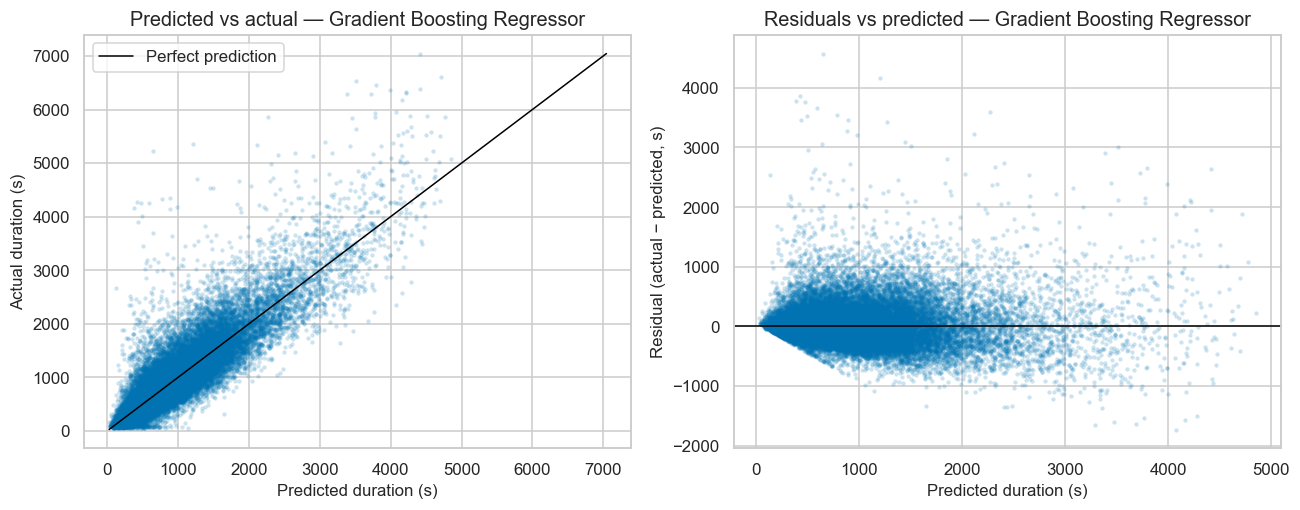

Residual mean: -1.55s   Residual std: 291.48s


In [ ]:
progress("Cluster H", "best-model residual plots")
official = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "ElasticNet Regression",
    "Polynomial Regression",
    "Decision Tree Regressor",
    "Random Forest Regressor",
    "Gradient Boosting Regressor",
    "Support Vector Regressor",
    "K-Nearest Neighbors Regressor",
]
# Prefer a tuned sibling if it beat its parent
candidates = pd.DataFrame(leaderboard)
candidates = candidates[candidates["Model"].isin(official + [
    "Ridge Regression (tuned)",
    "Random Forest Regressor (tuned)",
])]
best_name = candidates.sort_values("R2", ascending=False).iloc[0]["Model"]
y_best = predictions[best_name]
residuals = y_test.to_numpy() - y_best

print(f"Best model by test R2: {best_name}")
print(candidates.sort_values("R2", ascending=False).head(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].scatter(y_best, y_test, s=8, alpha=0.2, linewidths=0)
lims = [min(y_best.min(), y_test.min()), max(y_best.max(), y_test.max())]
axes[0].plot(lims, lims, color="black", linewidth=1, label="Perfect prediction")
axes[0].set_title(f"Predicted vs actual — {best_name}")
axes[0].set_xlabel("Predicted duration (s)")
axes[0].set_ylabel("Actual duration (s)")
axes[0].legend()

axes[1].scatter(y_best, residuals, s=8, alpha=0.2, linewidths=0)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title(f"Residuals vs predicted — {best_name}")
axes[1].set_xlabel("Predicted duration (s)")
axes[1].set_ylabel("Residual (actual − predicted, s)")

finalise(fig)
print(f"Residual mean: {residuals.mean():.2f}s   Residual std: {residuals.std():.2f}s")


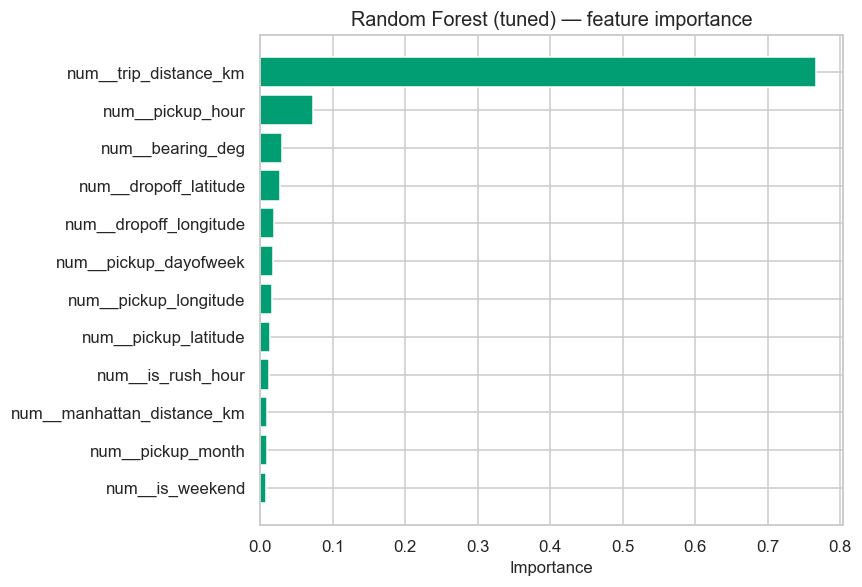

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
importance_model = forest_tuned if "forest_tuned" in dir() else forest
imp_source = "Random Forest (tuned)" if importance_model is not forest else "Random Forest"
series = (
    pd.Series(importance_model.feature_importances_, index=feature_names)
    .sort_values(ascending=True)
    .tail(12)
)
ax.barh(series.index, series.values, color=sns.color_palette("colorblind")[2])
ax.set_title(f"{imp_source} — feature importance")
ax.set_xlabel("Importance")
finalise(fig)


**Reading the diagnostics.** A good predicted-vs-actual plot follows the diagonal for typical trips (200–2000 s) and fans out on rare long trips. A funnel-shaped residual plot means the model is worse on long trips — expected, because we have no live traffic feature. Residual mean near 0 means “unbiased, but not perfect.”


### H4. 5-fold cross-validation (two best official models)

The guidelines require 5-fold CV R² for the **two best-performing** models. Every G-cell already computed those folds. This cell only **selects the top two by test R²** and reprints their CV numbers so the rubric item is one place in the notebook.


If the top two are SVR or KNN, the CV numbers come from their training subset (same rows used to fit). Otherwise they come from the full processed training table. No second fit is needed — Cluster G already stored `CV R2 mean` / `std` / fold scores.


In [ ]:
progress("Cluster H", "5-fold CV of top two")
official = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "ElasticNet Regression",
    "Polynomial Regression",
    "Decision Tree Regressor",
    "Random Forest Regressor",
    "Gradient Boosting Regressor",
    "Support Vector Regressor",
    "K-Nearest Neighbors Regressor",
]
ranked_official = (
    pd.DataFrame(leaderboard)
    .query("Model in @official")
    .sort_values("R2", ascending=False)
)
top_two_names = ranked_official["Model"].head(2).tolist()
print("Top two official models by test R²:", top_two_names)
print()
print("Each already has test R² / RMSE / MAE and 5-fold CV R² from Cluster G.")
print("Reprinted here because the rubric asks for CV on the two best models.\n")

cv_rows = []
for name in top_two_names:
    row = next(r for r in leaderboard if r["Model"] == name)
    show_mandatory_metrics(name, row)
    cv_rows.append(
        {
            "Model": name,
            "Test R2": row["R2"],
            "Test RMSE": row["RMSE"],
            "Test MAE": row["MAE"],
            "CV folds": 5,
            "CV R2 mean": row["CV R2 mean"],
            "CV R2 std": row["CV R2 std"],
            "Fold scores": row["CV folds"],
        }
    )

display(pd.DataFrame(cv_rows))


[09:05:32] Cluster H  |  5-fold CV of top two — slow


[09:05:32] Cluster H  |  5-fold CV of top two — slow


Top two official models by test R2: ['Gradient Boosting Regressor', 'Random Forest Regressor']
[09:05:32] CV  |  Gradient Boosting Regressor


[09:05:32] CV  |  Gradient Boosting Regressor


Gradient Boosting Regressor: fold R2 = [0.7915 0.7971 0.793  0.7891 0.7888]  mean=0.7919  std=0.0030
[09:05:37] CV  |  Random Forest Regressor


[09:05:37] CV  |  Random Forest Regressor


---
# Cluster I : Manual tester

**Input:** the fitted models and the **same** `preprocess` object from Cluster F.  
**Output:** predicted duration (seconds and minutes) for a trip **you type in**.

Change the numbers in the next code cell, then re-run **that cell only**. The helper builds the same engineered columns as Cluster E, scales with the **already fitted** train scaler (no refitting), and scores the current best model plus the other fitted models.


In [ ]:
progress("Cluster I", "manual tester")
# =============================================================================
# EDIT THIS DICTIONARY, then re-run this cell.
# Coordinates are WGS84. pickup_datetime is local NYC time.
# vendor_id is 1 or 2. store_and_fwd_flag is "N" or "Y".
# =============================================================================
manual_trip = {
    "vendor_id": 2,
    "pickup_datetime": "2016-03-14 17:24:55",  # weekday evening — rush hour
    "passenger_count": 1,
    "pickup_longitude": -73.9822,
    "pickup_latitude": 40.7679,
    "dropoff_longitude": -73.9646,
    "dropoff_latitude": 40.7656,
    "store_and_fwd_flag": "N",
}

# Optional second trip for a quick sanity check (set to None to skip)
manual_trip_b = {
    "vendor_id": 1,
    "pickup_datetime": "2016-06-12 00:43:35",  # late night
    "passenger_count": 2,
    "pickup_longitude": -73.9804,
    "pickup_latitude": 40.7386,
    "dropoff_longitude": -73.9995,
    "dropoff_latitude": 40.7312,
    "store_and_fwd_flag": "N",
}


def predict_manual_trips(*trips):
    rows = [t for t in trips if t is not None]
    raw = pd.DataFrame(rows)
    needed = [
        "vendor_id",
        "pickup_datetime",
        "passenger_count",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "store_and_fwd_flag",
    ]
    missing = [c for c in needed if c not in raw.columns]
    if missing:
        raise ValueError(f"manual trip is missing columns: {missing}")

    fe = engineer_features(raw)
    X_manual = fe.reindex(columns=X_train.columns)
    if X_manual.isna().any().any():
        raise ValueError("manual features contain NaN — check column names and types.")
    X_manual_p = preprocess.transform(X_manual)

    # Prefer the overall best fitted model (tuned variants included)
    rank = pd.DataFrame(leaderboard).sort_values("R2", ascending=False)
    best = rank.iloc[0]["Model"]
    if best not in fitted_models:
        best = rank.loc[rank["Model"].isin(fitted_models), "Model"].iloc[0]

    out = X_manual.copy()
    out.insert(0, "trip", range(1, len(out) + 1))
    out["predicted_seconds"] = np.clip(fitted_models[best].predict(X_manual_p), 1, None)
    out["predicted_minutes"] = out["predicted_seconds"] / 60.0
    out["model_used"] = best

    print(f"Best model used: {best}")
    print(f"Engineered distance (km): {fe['trip_distance_km'].round(3).tolist()}")
    print(f"Rush hour flag:           {fe['is_rush_hour'].tolist()}")
    display(
        out[
            [
                "trip",
                "model_used",
                "predicted_seconds",
                "predicted_minutes",
                "passenger_count",
                "trip_distance_km",
                "pickup_hour",
                "is_rush_hour",
            ]
        ]
    )

    # Also score every fitted official model on trip 1 (helps the viva)
    trip1 = X_manual_p[0:1]
    compare = []
    for name, model in fitted_models.items():
        try:
            pred = float(np.clip(model.predict(trip1), 1, None)[0])
        except Exception:
            continue
        compare.append({"Model": name, "Predicted seconds": pred, "Predicted minutes": pred / 60.0})
    compare_df = pd.DataFrame(compare).sort_values("Predicted seconds")
    print("\\nTrip 1 — every fitted model:")
    display(compare_df)

    return out, compare_df


manual_predictions, manual_model_compare = predict_manual_trips(manual_trip, manual_trip_b)


**How to use this.** Change `pickup_longitude` / `dropoff_longitude` (more negative = further west), the latitudes, passenger count, or the timestamp. A weekday 17:00 trip should come out **longer** than a Sunday 01:00 trip of similar distance. If predictions are identical after you move the dropoff 10 km, the tester is not wired to `preprocess` — re-run from Cluster F.

The values above are realistic NYC street-hail coordinates, not dummy zeros. They go through the **same** `engineer_features` → `preprocess.transform` path as the CSV.


---
# Cluster J : PDF report (OPTIONAL)

**Input:** every PNG saved by `finalise`, plus the live leaderboard, cleaning report, CV table, and manual-tester output.  
**Output:** `results/regression_report.pdf`.

Re-run this cluster after a full **Run All** (or after you change the manual trip) to refresh the PDF.


In [ ]:
progress("Cluster J", "writing PDF report")
PDF_PATH = RESULTS_DIR / "regression_report.pdf"
leaderboard_df = (
    pd.DataFrame(leaderboard)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)
leaderboard_df.insert(0, "Rank", leaderboard_df.index + 1)
cv_df = pd.DataFrame(cv_rows) if "cv_rows" in dir() else pd.DataFrame()


def _page_text(pdf, title, lines, fontsize=11):
    fig, ax = plt.subplots(figsize=(11.0, 8.5))
    ax.axis("off")
    ax.set_title(title, loc="left", fontsize=16, pad=12)
    text = "\n".join(lines)
    ax.text(0.02, 0.95, text, va="top", ha="left", fontsize=fontsize, family="DejaVu Sans", wrap=True)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def _page_table(pdf, title, frame, float_cols=None):
    show = frame.copy()
    float_cols = float_cols or []
    for c in float_cols:
        if c in show.columns:
            show[c] = show[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")
    fig, ax = plt.subplots(figsize=(11.0, max(4.0, 0.45 * (len(show) + 3))))
    ax.axis("off")
    ax.set_title(title, loc="left", fontsize=14, pad=10)
    tbl = ax.table(
        cellText=show.astype(str).values,
        colLabels=list(show.columns),
        loc="upper center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.0, 1.35)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def _page_image(pdf, path):
    img = plt.imread(path)
    h, w = img.shape[0], img.shape[1]
    aspect = h / max(w, 1)
    fig_w = 11.0
    fig_h = min(8.5, max(4.0, fig_w * aspect))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(path.stem.replace("_", " "), loc="left", fontsize=11)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


with PdfPages(PDF_PATH) as pdf:
    n_models = len([r for r in leaderboard if r["Model"] != "Mean baseline"])
    _page_text(
        pdf,
        "NYC Taxi Trip Duration — Regression Report",
        [
            "23CSE301 Machine Learning  |  Review 1  |  Regression track",
            "",
            f"Data file: {DATA_PATH.resolve()}",
            f"Raw rows loaded: {len(df_raw):,}",
            f"Rows after cleaning: {len(df):,}",
            f"Rows in modelling table: {len(df_fe):,}",
            f"Training rows: {len(X_train):,}    Evaluation rows: {len(y_test):,}",
            f"FAST_DEV = {FAST_DEV}",
            "",
            f"Best model by test R²: {best_name}",
            f"Official models trained: {n_models}",
            f"Figures exported: {len(SAVED_FIGURES)}",
            "",
            "Pipeline: audit → EDA → clean → engineer → split/encode/scale",
            "→ 10 models → compare/tune/CV → manual tester.",
            "Encoders and scalers were fit on the training split only.",
            "dropoff_datetime and id were never used as predictors.",
        ],
    )

    if "cleaning_report" in dir():
        _page_table(
            pdf,
            "Data cleaning — rows removed at each step",
            cleaning_report,
            float_cols=["pct_removed"],
        )

    metric_cols = [c for c in ["Rank", "Model", "Train rows", "R2", "RMSE", "MAE", "CV R2 mean", "CV R2 std", "Fit seconds"] if c in leaderboard_df.columns]
    _page_table(
        pdf,
        "Test metrics (same held-out trips for every model)",
        leaderboard_df[metric_cols],
        float_cols=["R2", "RMSE", "MAE", "CV R2 mean", "CV R2 std", "Fit seconds"],
    )

    if len(cv_df):
        show_cv = cv_df.copy()
        if "Fold scores" in show_cv.columns:
            show_cv["Fold scores"] = show_cv["Fold scores"].astype(str)
        _page_table(pdf, "5-fold CV R² for the two best official models", show_cv, float_cols=["CV R2 mean", "CV R2 std"])

    if "manual_predictions" in dir():
        cols = [
            c
            for c in [
                "trip",
                "model_used",
                "predicted_seconds",
                "predicted_minutes",
                "trip_distance_km",
                "pickup_hour",
                "is_rush_hour",
            ]
            if c in manual_predictions.columns
        ]
        _page_table(
            pdf,
            "Manual tester — predicted duration for user-edited trips",
            manual_predictions[cols],
            float_cols=["predicted_seconds", "predicted_minutes", "trip_distance_km"],
        )

    for path in SAVED_FIGURES:
        if Path(path).exists():
            _page_image(pdf, Path(path))

print(f"Wrote {PDF_PATH.resolve()}")
print(f"Pages include {len(SAVED_FIGURES)} figures + metric / cleaning / manual-tester tables.")
print("PNG copies live in:", FIG_DIR.resolve())


---
# Rubric coverage (Review 1)

This notebook is the **Regression track** plus shared **Dataset / EDA / Preprocessing**.  
Source: *23CSE301 Machine Learning — Capstone Guidelines* (Review 1, 25 marks).  
**Yes** = implemented here. **No** = not this file (other Review 1 items live in a classification notebook or in the live presentation).

## Section A — Dataset & EDA (4 marks)

| ID | Marks | Rubric requirement | Status | Where in this notebook |
|---|---|---|---|---|
| **A1** | 1 | Load the data and audit it: shape, dtypes, missing-value counts, and target distribution, all reported clearly | **Yes** | **Cluster B** — load CSV; audit table (`dtype`, `missing`, `n_unique`); `trip_duration.describe`; vendor / passenger / flag counts |
| **A2** | 2 | EDA plots, at minimum: distribution plots for features, correlation heatmap, target distribution, and at least two scatter plots of feature vs target | **Yes** | **Cluster C** — target hist (raw + log1p); passenger / vendor / hour / weekday; pickup & dropoff maps (coordinate distributions); distance vs duration scatter; hour vs duration boxplot; raw correlation heatmap. **Cluster E** — engineered heatmap; cleaned distance scatter; rush-hour boxplot |
| **A3** | 1 | Each major plot followed by a written observation (Markdown) saying what it shows | **Yes** | Markdown immediately under each C/E figure (“Reading this plot / heatmap”) |

## Section B — Preprocessing & Feature Engineering (3 marks)

| ID | Marks | Rubric requirement | Status | Where in this notebook |
|---|---|---|---|---|
| **B1** | 1 | Missing values handled with a justified strategy; duplicates and outliers checked and treated | **Yes** | **Cluster B** (missing = 0, so no imputation — stated explicitly). **Cluster D** — duplicate check; NYC GPS box; passenger 1–6; duration 60–7200 s; no silent `dropna`; no IQR wipe of real airport trips |
| **B2** | 1 | Encode categoricals; scaler fit on **train only**; stratified train/test split | **Yes** | **Cluster F** — `qcut` duration bins + `stratify`; `OneHotEncoder` on `vendor_id` and `store_and_fwd_flag`; `StandardScaler` on numerics; `ColumnTransformer.fit` on `X_train` only |
| **B3** | 1 | At least one engineered feature, with a written reason it should help | **Yes** | **Cluster E** — haversine km, Manhattan km, bearing, hour / weekday / month, `is_weekend`, `is_rush_hour`; justification table in the E1 markdown |

## Section C — Regression track (9 marks)

| ID | Marks | Rubric requirement | Status | Where in this notebook |
|---|---|---|---|---|
| **C1** | 4 | All **10** required algorithms trained, predictions produced, no errors | **Yes** | **Cluster G** — (1) Linear, (2) Ridge, (3) Lasso, (4) ElasticNet, (5) Polynomial, (6) Decision Tree, (7) Random Forest, (8) Gradient Boosting (`HistGradientBoostingRegressor`), (9) SVR, (10) KNN. Mean baseline is extra, not one of the ten |
| **C2** | 2 | One summary table of R², RMSE, MAE for all 10 on the **same** test split; ranked by R² | **Yes** | **Each G-cell** prints R² / RMSE / MAE / 5-fold CV R². **Cluster H1** ranks them on the shared test set |
| **C3** | 2 | `GridSearchCV` or `RandomizedSearchCV` on **at least 2** models; best params and metric improvement reported | **Yes** | **Cluster H2** — `GridSearchCV` on Ridge `alpha`; `RandomizedSearchCV` on Random Forest, then refit on full train; before vs after test R² printed |
| **C4** | 1 | Residual plot and predicted-vs-actual for the **best** model; feature importance for at least one tree model | **Yes** | **Cluster H3** — predicted vs actual + residuals. Tree importance in **G6** (Decision Tree) and again in H3 (Random Forest / tuned forest) |

### Also required in the general guidelines (not a separate letter, but marked if missing)

| Requirement | Status | Where |
|---|---|---|
| 5-fold cross-validated R² for the **two best** models | **Yes** | **Every G-cell** prints 5-fold CV R² after the fit. **Cluster H4** reprints the two best. |
| `random_state=42` | **Yes** | **Cluster A** and every splitter / model that accepts it |
| Scaler / encoder never fit on the full dataset | **Yes** | **Cluster F** |
| Markdown explaining major blocks | **Yes** | Cluster titles A–J |

## Section D — Classification Part A (3 marks) — **not this notebook**

Review 1 also asks for Classification Part A. That is a **different track** (`classification.ipynb` when you build it). Nothing below is implemented in `regression.ipynb`.

| ID | Marks | Rubric requirement | Status | Where |
|---|---|---|---|---|
| **D1** | 2 | All 5 Part-A classifiers trained (Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM) | **No** | Needs **classification notebook**, Cluster equivalent of G |
| **D2** | 1 | Accuracy, weighted F1, confusion matrix per algorithm; preliminary comparison table | **No** | Same classification notebook |

## Section E — Presentation & viva (6 marks) — **not code**

| ID | Marks | Rubric requirement | Status | Where |
|---|---|---|---|---|
| **E1** | 1 | Clear narrative; all team members can explain the code | **In person** | Live Review 1 presentation. This notebook’s cluster story is the slide backbone |
| **Viva** | 5 | Questions on any part of the work | **In person** | Use Cluster H5 + `Regression_Notebook_Guide.pdf` |

## Mark map for *this file*

| Block | Rubric IDs it carries |
|---|---|
| **A** Setup | reproducibility (`random_state=42`) |
| **B** Audit | **A1** |
| **C** EDA | **A2**, **A3** |
| **D** Cleaning | **B1** |
| **E** Feature engineering | **B3** (and extra A2/A3 plots) |
| **F** Split / encode / scale | **B2** |
| **G** Ten models | **C1** (and tree importance for C4) |
| **H** Compare / tune / diagnostics / CV | **C2**, **C3**, **C4**, 5-fold CV |
| **I** Manual tester | not on the rubric (demo / viva extra) |
| **J** Results PDF | not on the rubric (submission extra) |

**Regression-side Review 1 code: A1–A3, B1–B3, C1–C4 = 16 / 16 of the notebook marks.**  
Still outside this file for the full 25: Classification D1–D2 (3), Presentation E1 (1), Viva (5).
